In [1]:
import getdist.plots as gdplots
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
import cmocean
import importlib
import cmocean.cm as cmo

from getdist import MCSamples, loadMCSamples
from scipy.stats import norm, uniform
from pathlib import Path

import src.analysis.plots as plots
import src.statistics.corrfiles as cf
import corner_utils as corners

cmap = cmo.dense
PAPER_FIGURES_ROOT = Path(
    "/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/"
)

pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)
CHAIN_ROOT = cf.get_base_dir() / "cosmic_shear" / "chains"
default_file = "hsc-y3-shear.txt"

Removed no burn in
Removed no burn in
Removed no burn in

=== All Bins ===
cosmological_parameters--omega_m    | Mode: 0.2218, MAP: 0.2425, Mean: 0.2299 68%-: 0.1862, 68%+: 0.2550, 95%-: 0.1099, 95%+: 0.2781, LaTeX: $0.222^{+0.033}_{-0.036}\;(0.243)$
COSMOLOGICAL_PARAMETERS--S_8        | Mode: 0.8046, MAP: 0.8153, Mean: 0.8050 68%-: 0.7860, 68%+: 0.8227, 95%-: 0.7646, 95%+: 0.8382, LaTeX: $0.805^{+0.018}_{-0.019}\;(0.815)$
COSMOLOGICAL_PARAMETERS--SIGMA_8    | Mode: 0.9166, MAP: 0.9068, Mean: 0.9281 68%-: 0.8412, 68%+: 0.9872, 95%-: 0.6092, 95%+: 1.0379, LaTeX: $0.917^{+0.071}_{-0.075}\;(0.907)$
wl_photoz_errors--bias_3            | Mode: 0.0064, MAP: 0.0010, Mean: 0.0077 68%-: -0.0092, 68%+: 0.0212, 95%-: -0.0588, 95%+: 0.0327, LaTeX: $0.006^{+0.015}_{-0.016}\;(0.001)$
wl_photoz_errors--bias_4            | Mode: 0.0022, MAP: -0.0012, Mean: 0.0028 68%-: -0.0098, 68%+: 0.0136, 95%-: -0.0272, 95%+: 0.0227, LaTeX: $0.002^{+0.011}_{-0.012}\;(-0.001)$

=== No Bin 4 ===
cosmological_paramete

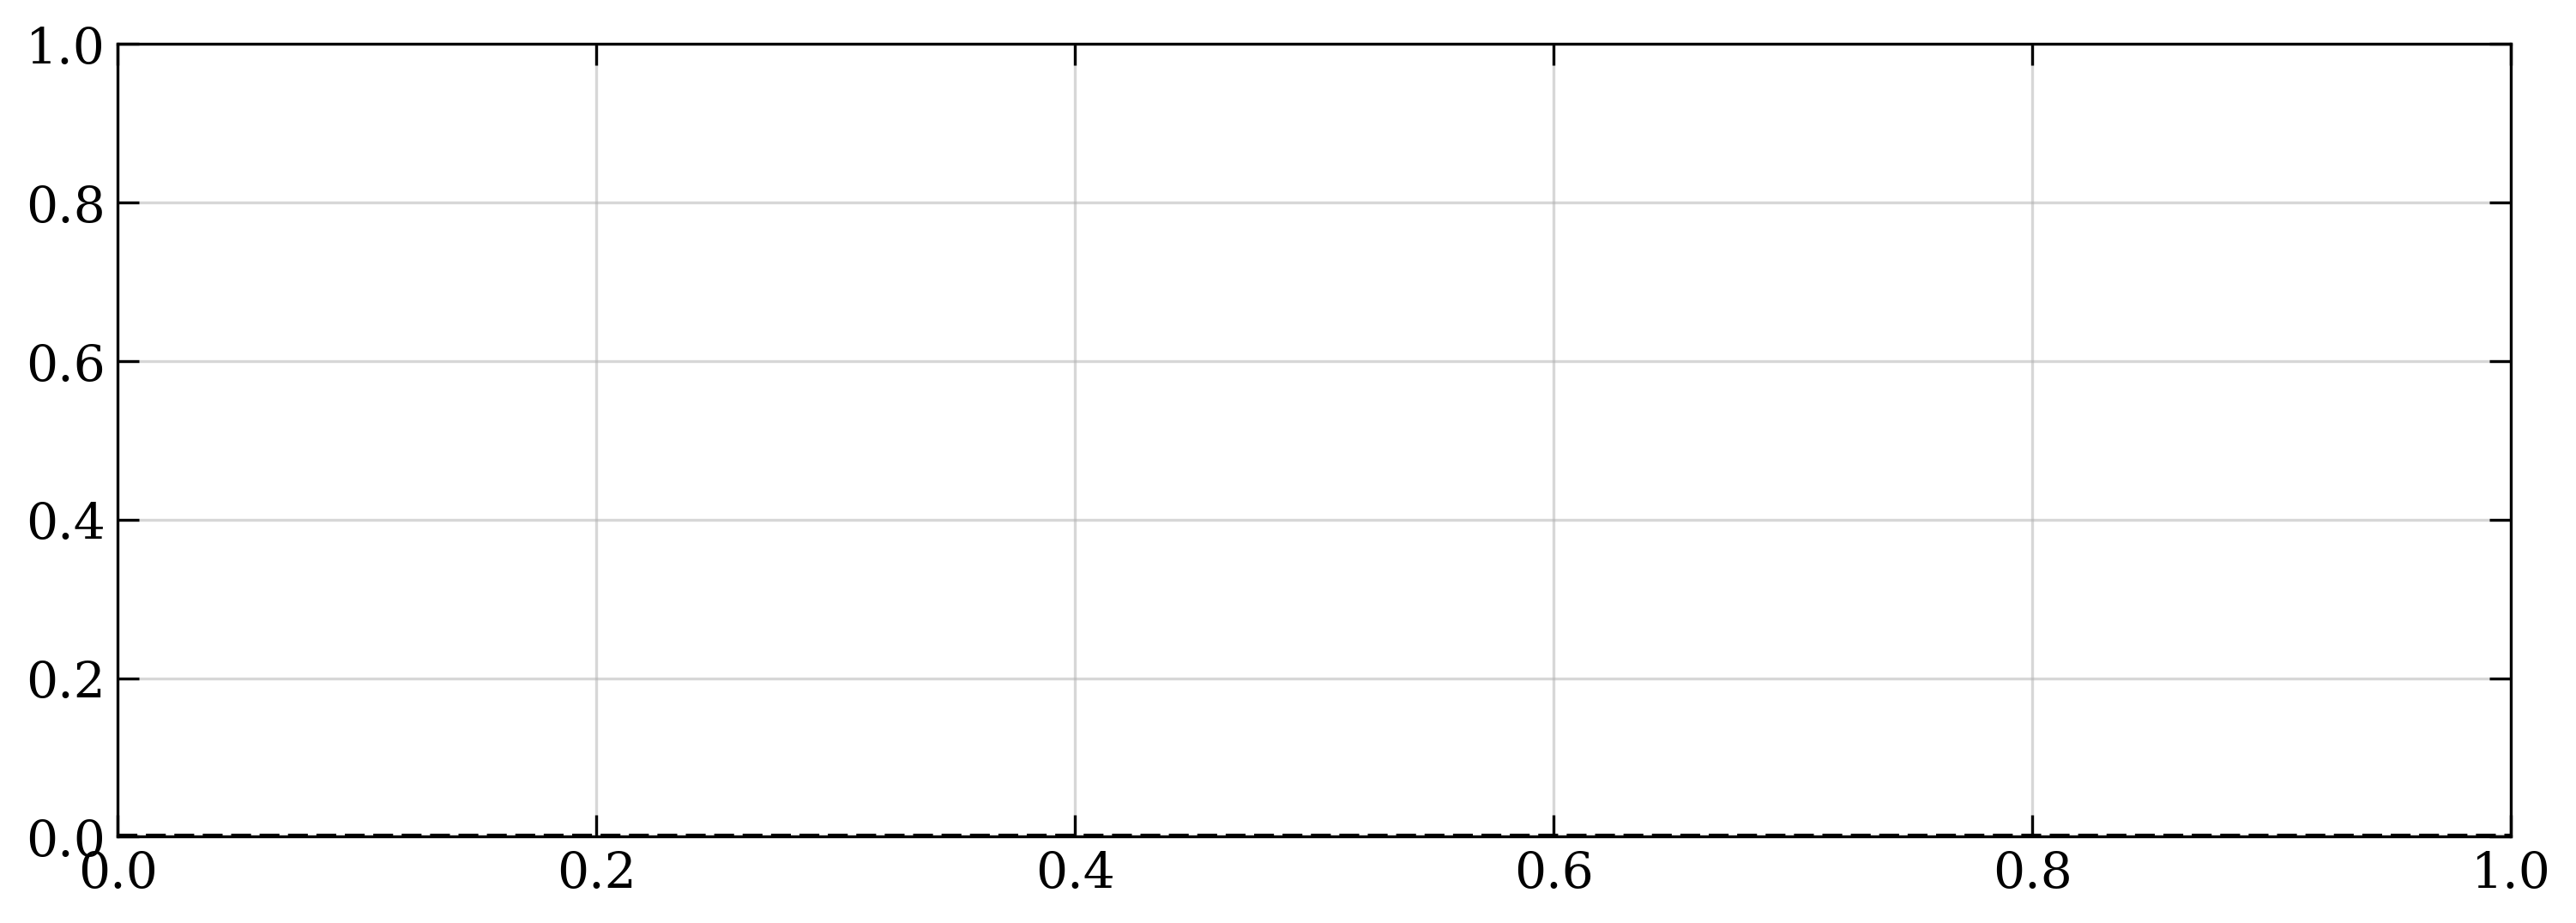

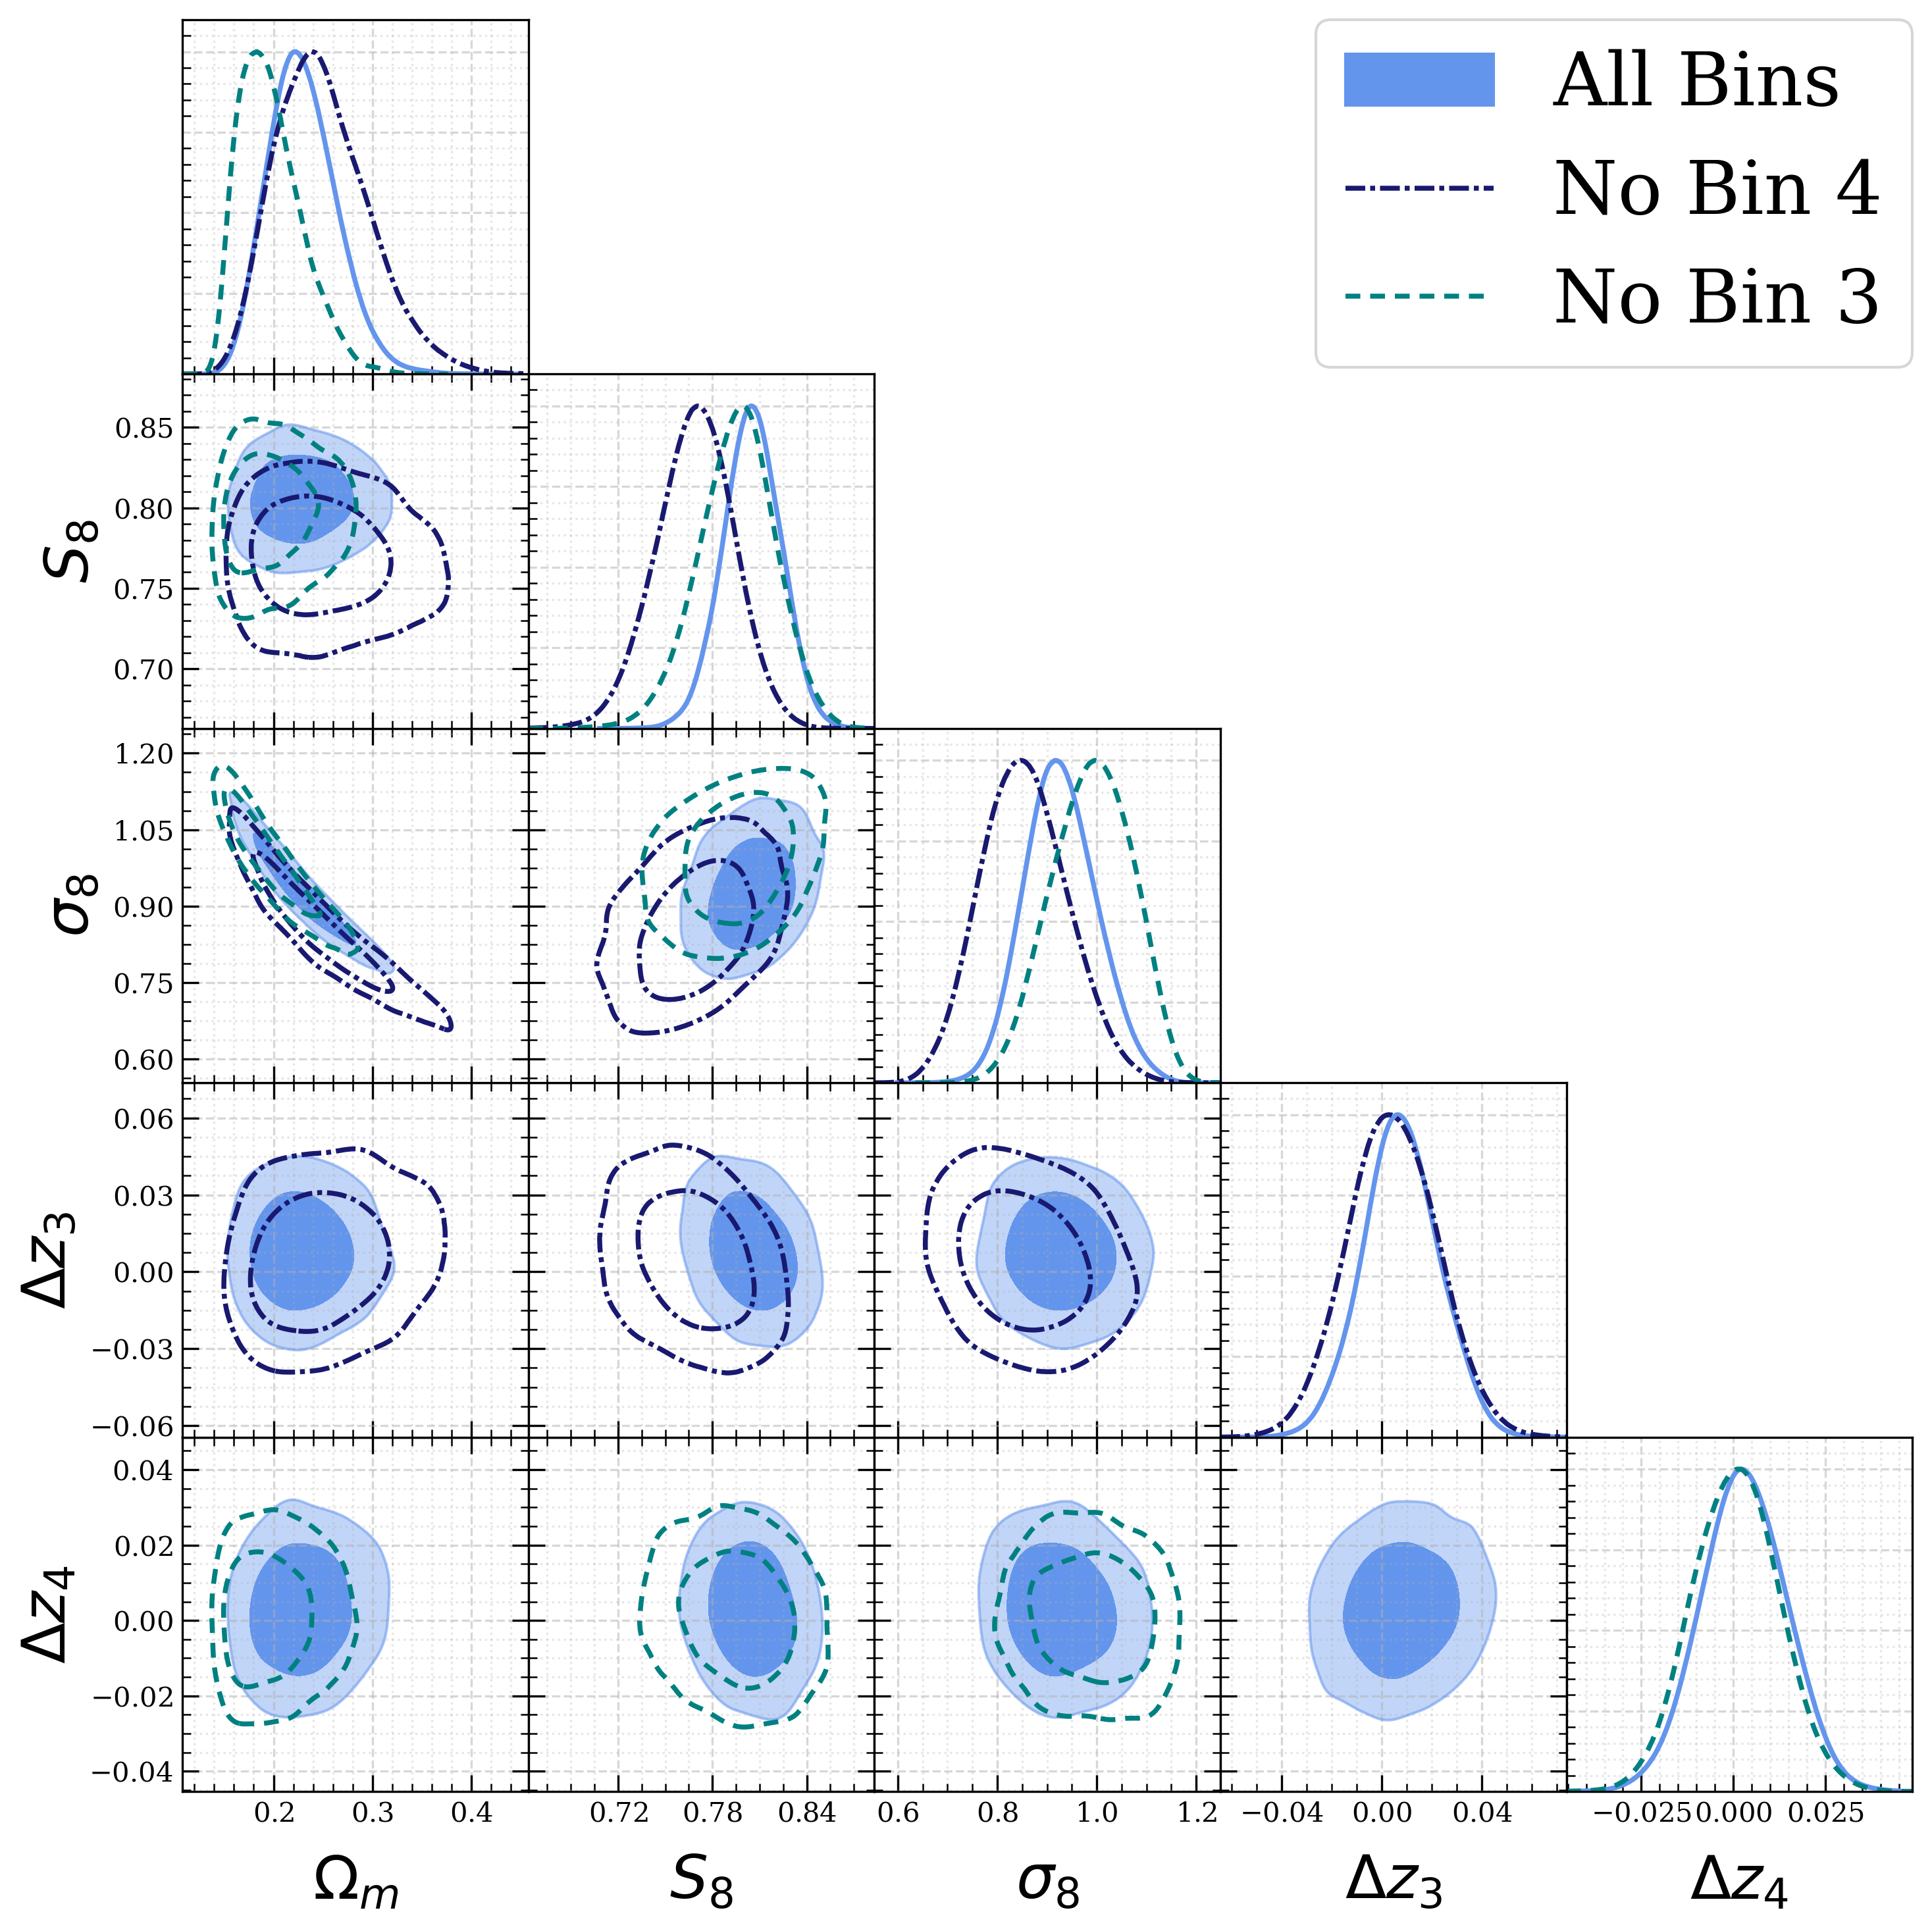

In [4]:
importlib.reload(corners)
out_summary = Path("summaries/summary_bin_exclusions.txt")
out_summary.parent.mkdir(exist_ok=True)
if out_summary.exists():
    out_summary.unlink()

fiducial_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-fiducial" / default_file
no_z3_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-no_z3" / default_file
no_z4_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-no_z4" / default_file

chain_files = [no_z3_file, no_z4_file, fiducial_file]
chain_labels = ["No Bin 3", "No Bin 4", "All Bins"]
params = [
    "cosmological_parameters--omega_m",
    "COSMOLOGICAL_PARAMETERS--S_8",
    "COSMOLOGICAL_PARAMETERS--SIGMA_8",
    "wl_photoz_errors--bias_3",
    "wl_photoz_errors--bias_4",
]
param_labels = [r"\Omega_m", r"S_8", r"\sigma_8", r"\Delta z_3", r"\Delta z_4"]
base_burn = 0.15

df1, header1, prior_rescale1 = corners.load_and_process_data(
    no_z3_file, pop_params="wl_photoz_errors--bias_3"
)
df2, header2, prior_rescale2 = corners.load_and_process_data(
    no_z4_file, pop_params="wl_photoz_errors--bias_4"
)
df3, header3, prior_rescale3 = corners.load_and_process_data(fiducial_file)
## check prior rescale are all 1
assert np.allclose(prior_rescale1, 1.0)
assert np.allclose(prior_rescale2, 1.0)
assert np.allclose(prior_rescale3, 1.0)

samples1, ndf1, w1 = corners.make_mc_sample(
    df1,
    params,
    param_labels,
    prior_rescale1,
    chain_labels[0],
    burn=base_burn,
    use_log_weight=True,
)
samples2, ndf2, w2 = corners.make_mc_sample(
    df2,
    params,
    param_labels,
    prior_rescale2,
    chain_labels[1],
    burn=base_burn,
    use_log_weight=True,
)
samples3, ndf3, w3 = corners.make_mc_sample(
    df3,
    params,
    param_labels,
    prior_rescale3,
    chain_labels[2],
    burn=base_burn,
    use_log_weight=True,
)

samples_list = [samples1, samples2, samples3]

colors = ["teal", "midnightblue", "cornflowerblue"]
linestyles = ["--", "-.", "-"]
filled = [False, False, True]

assert len(colors) == len(linestyles) == len(filled) == len(samples_list)
assert len(params) == len(param_labels)


def do_mask(data, mask):
    a = [d for d, m in zip(data, mask) if m]
    a.reverse()
    return a


mask = [True, True, True]

corners.summarize_samples(
    dfs_list=do_mask([ndf1, ndf2, ndf3], mask),
    samples_list=do_mask([samples1, samples2, samples3], mask),
    params=params,
    filename=out_summary,
    colors=colors,
    linestyles=linestyles,
)

print(f"\nPosterior summary also saved to {out_summary}")

plots.plot_settings()
g = gdplots.get_subplot_plotter(rc_sizes=True)
g.settings.fontsize = 13
g.settings.axis_tick_max_labels = 4
g.settings.axes_fontsize = 13
g.settings.axes_labelsize = 25
g.settings.legend_fontsize = 30
g.settings.legend_loc = "upper right"

g.triangle_plot(
    do_mask(samples_list, mask),
    params,
    filled=do_mask(filled, mask),
    line_args=[
        {"color": c, "ls": ls, "lw": 1.2}
        for c, ls in zip(do_mask(colors, mask), do_mask(linestyles, mask))
    ],
    contour_colors=do_mask(colors, mask),
    contour_ls=do_mask(linestyles, mask),
    contour_lws=[1.8] * np.sum(mask),
    legend_loc="upper right",
    legend_labels=do_mask(chain_labels, mask),
)

for ax in g.subplots.flatten():
    if ax:
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.grid(which="minor", linestyle=":", alpha=0.3)

plt.savefig(PAPER_FIGURES_ROOT / "corner_excluded_bins.png")
plt.show()

Removed no burn in
Removed no burn in

=== $[1,\,5]$h$^{-1}$Mpc ===
cosmological_parameters--omega_m    | Mode: 0.2139, MAP: 0.2570, Mean: 0.2270 68%-: 0.1750, 68%+: 0.2478, 95%-: 0.1132, 95%+: 0.2678, LaTeX: $0.214^{+0.034}_{-0.039}\;(0.257)$
COSMOLOGICAL_PARAMETERS--S_8        | Mode: 0.8046, MAP: 0.8159, Mean: 0.8013 68%-: 0.7861, 68%+: 0.8254, 95%-: 0.7743, 95%+: 0.8865, LaTeX: $0.805^{+0.021}_{-0.018}\;(0.816)$
COSMOLOGICAL_PARAMETERS--SIGMA_8    | Mode: 0.9343, MAP: 0.8815, Mean: 0.9303 68%-: 0.8622, 68%+: 1.0158, 95%-: 0.8101, 95%+: 1.2665, LaTeX: $0.934^{+0.081}_{-0.072}\;(0.882)$

=== $[0.3,\,3]$h$^{-1}$Mpc ===
cosmological_parameters--omega_m    | Mode: 0.2218, MAP: 0.2425, Mean: 0.2299 68%-: 0.1862, 68%+: 0.2550, 95%-: 0.1099, 95%+: 0.2781, LaTeX: $0.222^{+0.033}_{-0.036}\;(0.243)$
COSMOLOGICAL_PARAMETERS--S_8        | Mode: 0.8046, MAP: 0.8153, Mean: 0.8050 68%-: 0.7860, 68%+: 0.8227, 95%-: 0.7646, 95%+: 0.8382, LaTeX: $0.805^{+0.018}_{-0.019}\;(0.815)$
COSMOLOGICAL_PARAMET

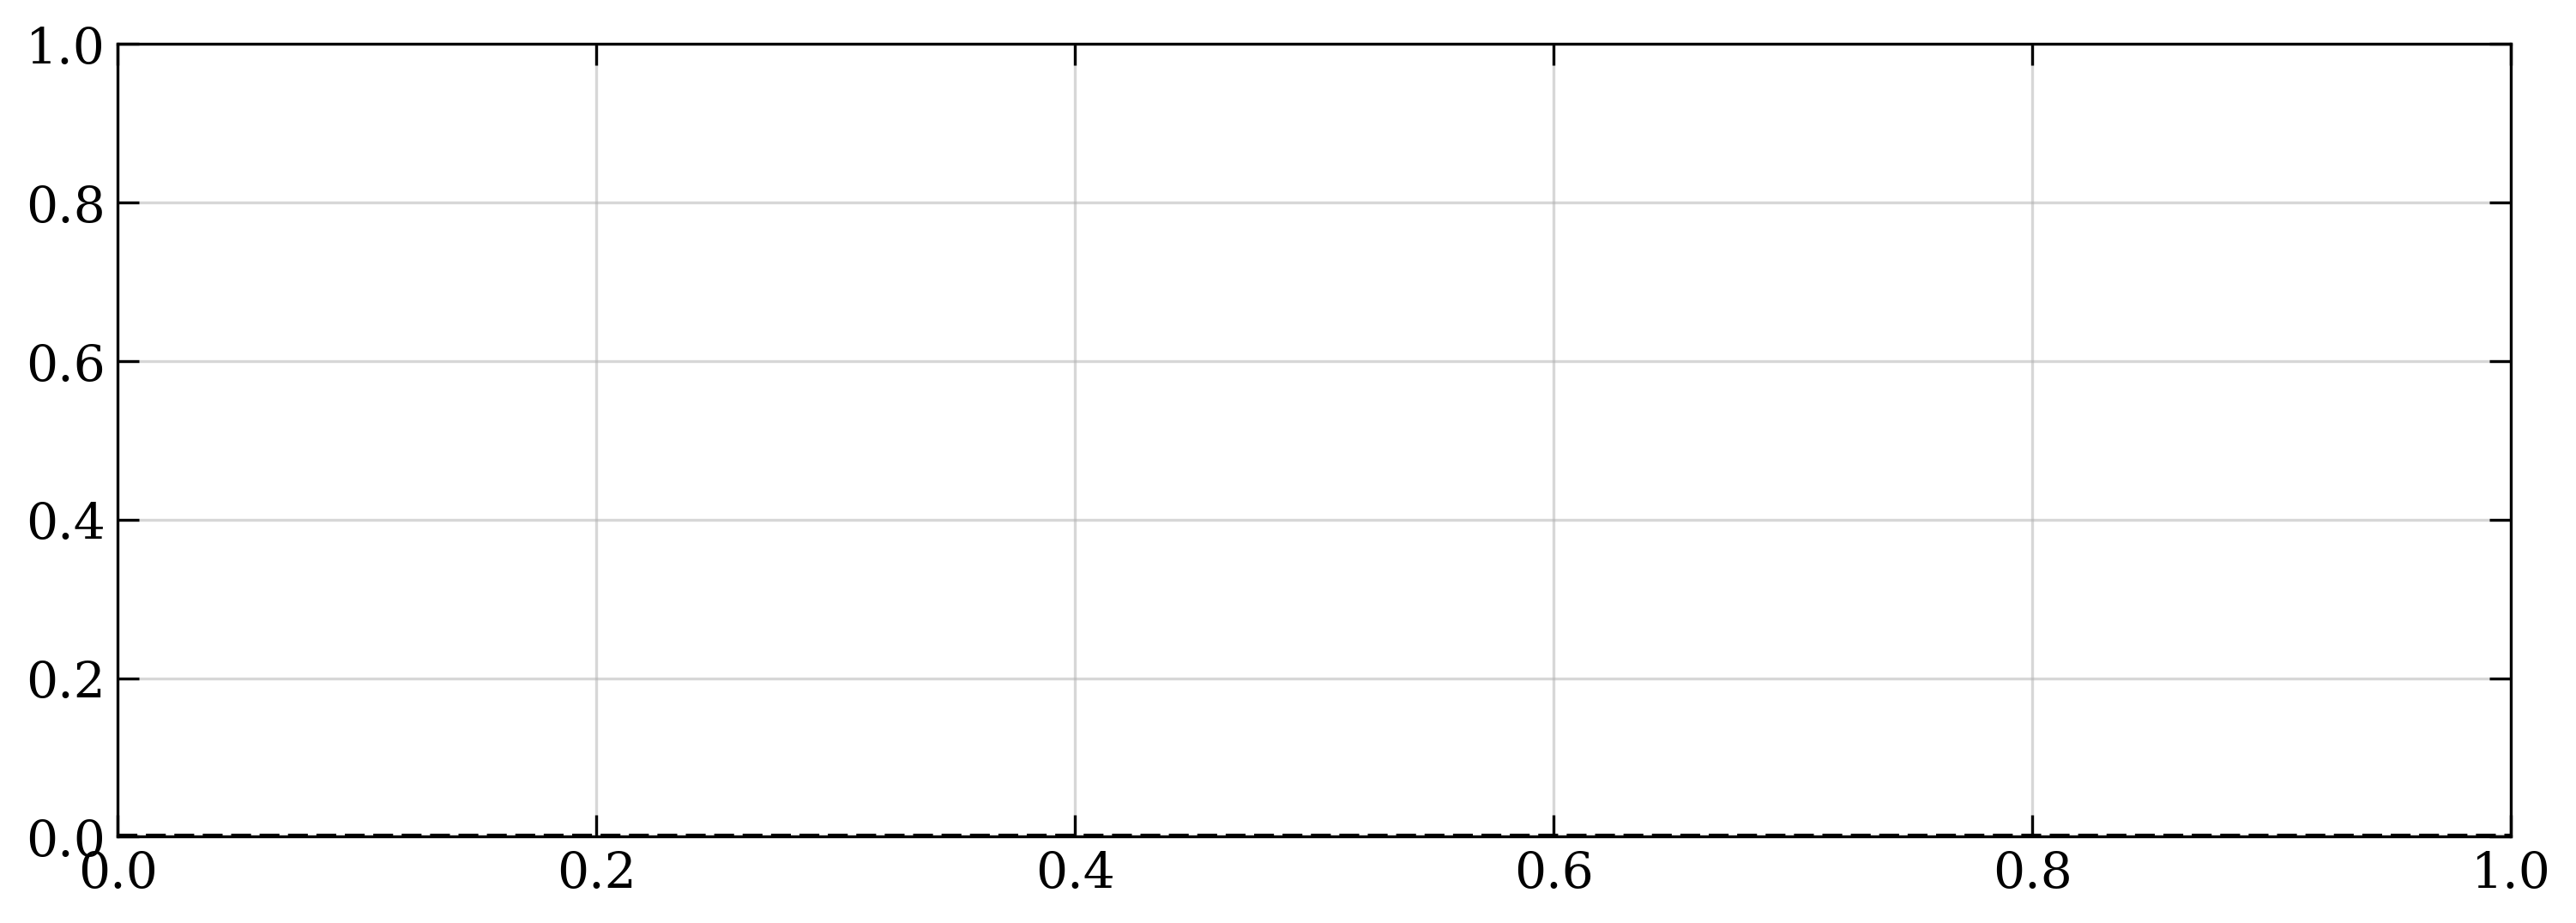

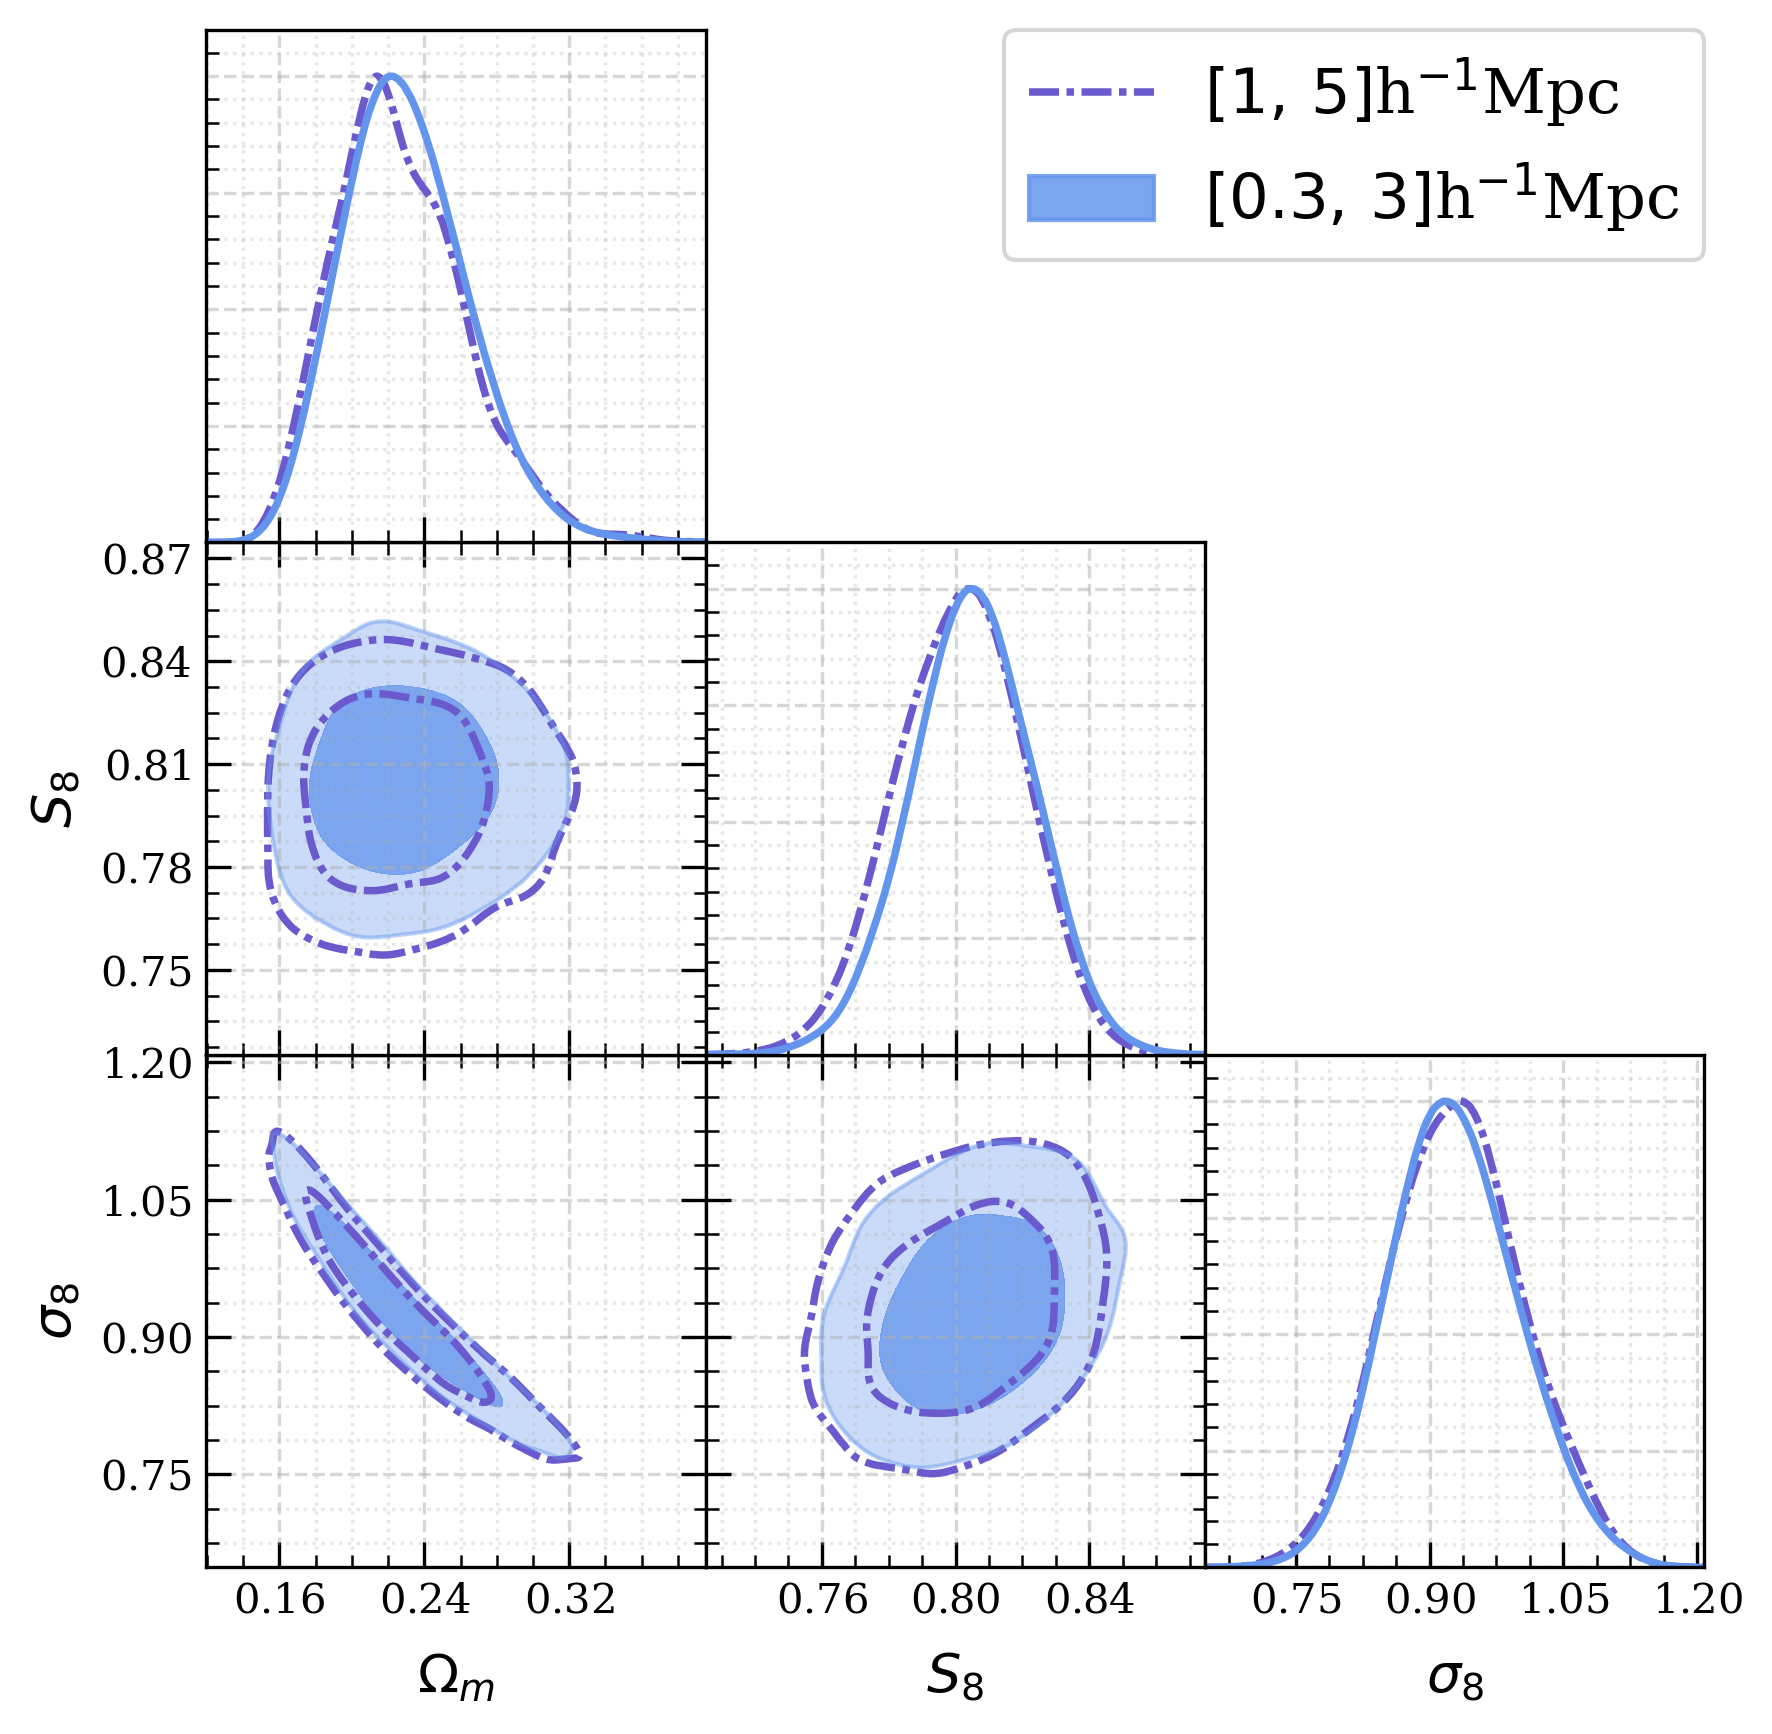

In [5]:
importlib.reload(corners)
out_summary = Path("summaries/summary_scale_cuts.txt")
out_summary.parent.mkdir(exist_ok=True)
if out_summary.exists():
    out_summary.unlink()

sc03_3_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-fiducial" / default_file
sc1_5_file = CHAIN_ROOT / "out-corrected-nz-real-1-5-fiducial" / default_file

chain_files = [sc03_3_file, sc1_5_file]
chain_labels = [r"$[0.3,\,3]$" + r"h$^{-1}$Mpc", r"$[1,\,5]$" + r"h$^{-1}$Mpc"]
params = [
    "cosmological_parameters--omega_m",
    "COSMOLOGICAL_PARAMETERS--S_8",
    "COSMOLOGICAL_PARAMETERS--SIGMA_8",
]
param_labels = [r"\Omega_m", r"S_8", r"\sigma_8"]

df1, header1, prior_rescale1 = corners.load_and_process_data(sc03_3_file)
df2, header2, prior_rescale2 = corners.load_and_process_data(sc1_5_file)
## check prior rescale are all 1
assert np.allclose(prior_rescale1, 1.0)
assert np.allclose(prior_rescale2, 1.0)

samples1, ndf1, w1 = corners.make_mc_sample(
    df1,
    params,
    param_labels,
    prior_rescale1,
    chain_labels[0],
    burn=base_burn,
    use_log_weight=True,
)
samples2, ndf2, w2 = corners.make_mc_sample(
    df2,
    params,
    param_labels,
    prior_rescale2,
    chain_labels[1],
    burn=base_burn,
    use_log_weight=True,
)
samples_list = [samples1, samples2]

colors = ["cornflowerblue", "slateblue"]
linestyles = ["-", "-."]
filled = [True, False]

assert len(colors) == len(linestyles) == len(filled) == len(samples_list)
assert len(params) == len(param_labels)


def do_mask(data, mask):
    a = [d for d, m in zip(data, mask) if m]
    a.reverse()
    return a


mask = [True, True]

corners.summarize_samples(
    dfs_list=do_mask([ndf1, ndf2], mask),
    samples_list=do_mask(samples_list, mask),
    params=params,
    filename=out_summary,
    colors=colors,
    linestyles=linestyles,
)

print(f"\nPosterior summary also saved to {out_summary}")

plots.plot_settings()
g = gdplots.get_subplot_plotter(rc_sizes=True)
g.settings.fontsize = 13
g.settings.axis_tick_max_labels = 4
g.settings.axes_fontsize = 13
g.settings.axes_labelsize = 16
g.settings.legend_fontsize = 18
g.settings.legend_loc = "upper right"

g.triangle_plot(
    do_mask(samples_list, mask),
    params,
    filled=do_mask(filled, mask),
    line_args=[
        {"color": c, "ls": ls, "lw": 1.2}
        for c, ls in zip(do_mask(colors, mask), do_mask(linestyles, mask))
    ],
    contour_colors=do_mask(colors, mask),
    contour_ls=do_mask(linestyles, mask),
    contour_lws=[1.8] * np.sum(mask),
    legend_loc="upper right",
    legend_labels=do_mask(chain_labels, mask),
)

for ax in g.subplots.flatten():
    if ax:
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.grid(which="minor", linestyle=":", alpha=0.3)

plt.savefig(PAPER_FIGURES_ROOT / "compare_scale_cuts.png")
plt.show()

0.007406707801303471 0.039
0.002709203436558098 0.048
0.020598590763234326 0.039
0.0040639128473576305 0.048


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in

=== HSC Y3 (Fiducial) ===
cosmological_parameters--omega_m    | Mode: 0.2449, MAP: 0.3042, Mean: 0.2575 68%-: 0.1991, 68%+: 0.2875, 95%-: 0.0850, 95%+: 0.3148, LaTeX: $0.245^{+0.043}_{-0.046}\;(0.304)$
COSMOLOGICAL_PARAMETERS--S_8        | Mode: 0.7711, MAP: 0.7816, Mean: 0.7699 68%-: 0.7422, 68%+: 0.8016, 95%-: 0.7195, 95%+: 0.8458, LaTeX: $0.771^{+0.031}_{-0.029}\;(0.782)$
COSMOLOGICAL_PARAMETERS--SIGMA_8    | Mode: 0.8374, MAP: 0.7761, Mean: 0.8418 68%-: 0.7553, 68%+: 0.9210, 95%-: 0.6740, 95%+: 0.9923, LaTeX: $0.837^{+0.084}_{-0.082}\;(0.776)$
wl_photoz_errors--bias_3            | Mode: 0.1110, MAP: 0.1196, Mean: 0.1170 68%-: 0.0611, 68%+: 0.1596, 95%-: -0.2235, 95%+: 0.1968, LaTeX: $0.111^{+0.049}_{-0.050}\;(0.120)$
wl_photoz_errors--bias_4            | Mode: 0.1823, MAP: 0.1902, Mean: 0.1869 68%-: 0.1050, 68%+: 0.2609, 95%-: 0.0296, 95%+: 0.3336, LaTeX: $0.182^{+0.079}_{-0.077}\;(0.190)$

=== HSC Y3 (Re-

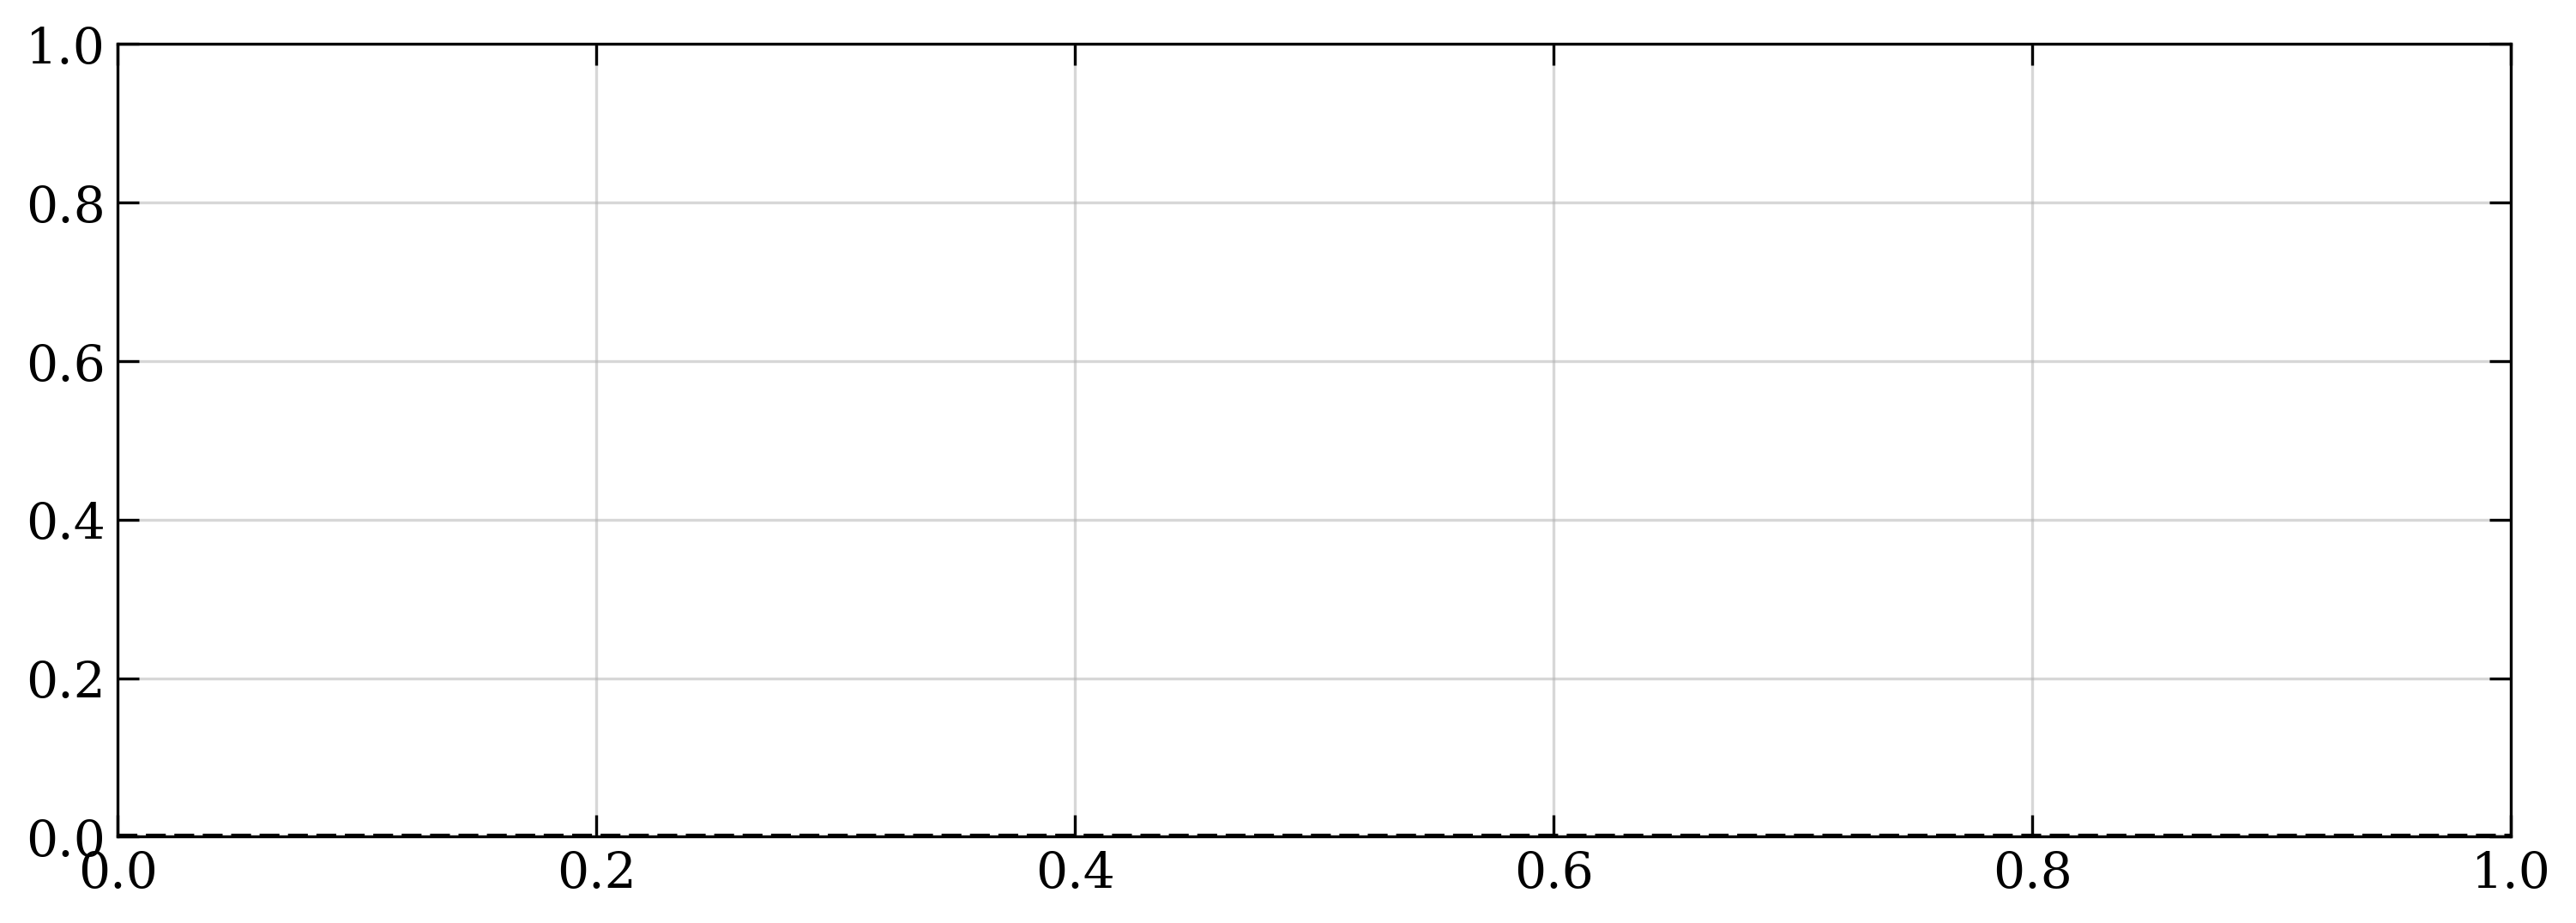

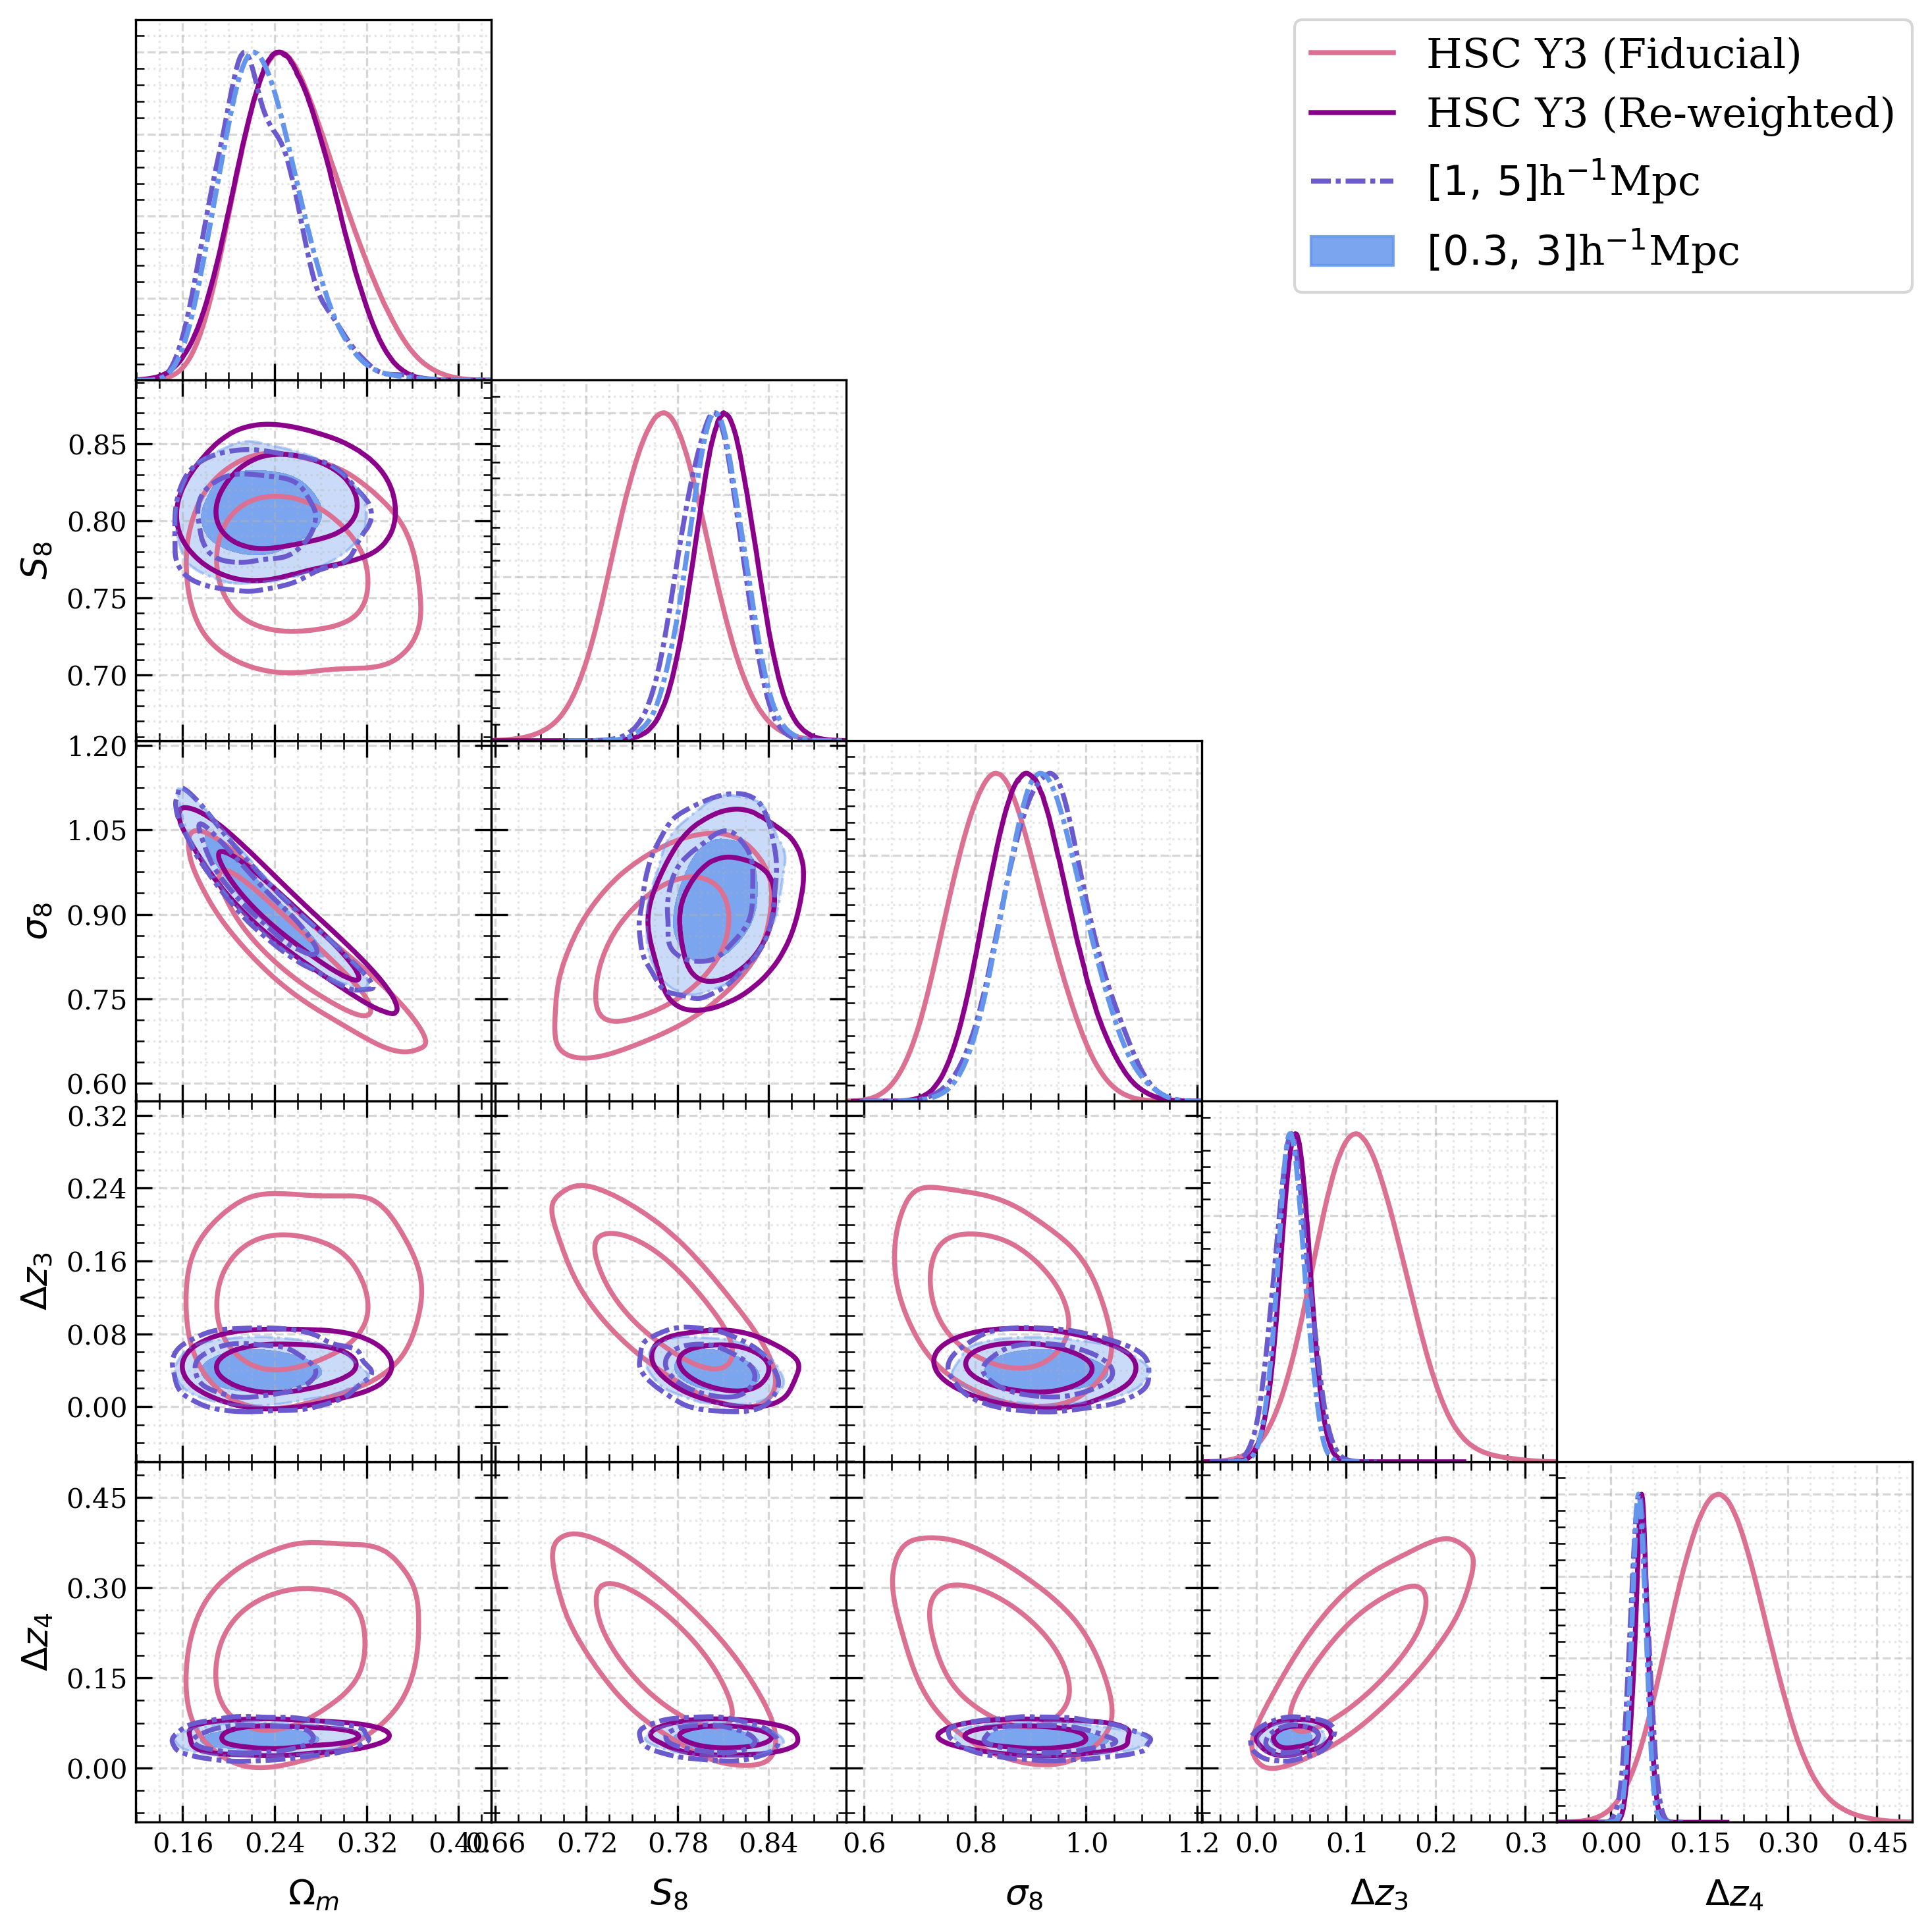

In [6]:
importlib.reload(corners)
out_summary = Path("summaries/summary_resampling.txt")
out_summary.parent.mkdir(exist_ok=True)
if out_summary.exists():
    out_summary.unlink()

sc03_3_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-fiducial" / default_file
sc1_5_file = CHAIN_ROOT / "out-corrected-nz-real-1-5-fiducial" / default_file
real_hscy3_file = CHAIN_ROOT / "ext" / "hsc_chains" / "hsc_y3_real.txt"

chain_files = [sc03_3_file, sc1_5_file, real_hscy3_file, real_hscy3_file]
chain_labels = [
    r"$[0.3,\,3]$" + r"h$^{-1}$Mpc",
    r"$[1,\,5]$" + r"h$^{-1}$Mpc",
    "HSC Y3 (Re-weighted)",
    "HSC Y3 (Fiducial)",
]
priors = {
    "wl_photoz_errors--bias_3": (0.039, 0.020),
    "wl_photoz_errors--bias_4": (0.048, 0.012),
}
old_priors = {
    "wl_photoz_errors--bias_1": norm(0, scale=0.024),
    "wl_photoz_errors--bias_2": norm(0, scale=0.022),
    "wl_photoz_errors--bias_3": uniform(loc=-1, scale=2.0),
    "wl_photoz_errors--bias_4": uniform(loc=-1, scale=2.0),
}
params = [
    "cosmological_parameters--omega_m",
    "COSMOLOGICAL_PARAMETERS--S_8",
    "COSMOLOGICAL_PARAMETERS--SIGMA_8",
    "wl_photoz_errors--bias_3",
    "wl_photoz_errors--bias_4",
]
param_labels = [r"\Omega_m", r"S_8", r"\sigma_8", r"\Delta z_3", r"\Delta z_4"]

rename_priors = {
    f"nz_sample_errors--bias_{i}": f"wl_photoz_errors--bias_{i}" for i in range(1, 5)
}
df1, header1, prior_rescale1 = corners.load_and_process_data(
    sc03_3_file, displace_mean_frompriors=priors
)
df2, header2, prior_rescale2 = corners.load_and_process_data(
    sc1_5_file, displace_mean_frompriors=priors
)
df3, header3, prior_rescale3 = corners.load_and_process_data(
    real_hscy3_file, new_priors=priors, rename_priors=rename_priors
)
df4, header4, prior_rescale4 = corners.load_and_process_data(
    real_hscy3_file, rename_priors=rename_priors
)
## check prior rescale are all 1
assert np.allclose(prior_rescale1, 1.0)
assert np.allclose(prior_rescale2, 1.0)

samples1, ndf1, w1 = corners.make_mc_sample(
    df1,
    params,
    param_labels,
    prior_rescale1,
    chain_labels[0],
    burn=base_burn,
    use_log_weight=True,
)
samples2, ndf2, w2 = corners.make_mc_sample(
    df2,
    params,
    param_labels,
    prior_rescale2,
    chain_labels[1],
    burn=base_burn,
    use_log_weight=True,
)
samples3, ndf3, w3 = corners.make_mc_sample(
    df3, params, param_labels, prior_rescale3, chain_labels[2], burn=base_burn
)
samples4, ndf4, w4 = corners.make_mc_sample(
    df4, params, param_labels, prior_rescale4, chain_labels[3], burn=0
)

samples_list = [samples1, samples2, samples3, samples4]

colors = ["cornflowerblue", "slateblue", "darkmagenta", "palevioletred"]
linestyles = ["-.", "-.", "-", "-"]
filled = [True, False, False, False]

assert len(colors) == len(linestyles) == len(filled) == len(samples_list)
assert len(params) == len(param_labels)


def do_mask(data, mask):
    a = [d for d, m in zip(data, mask) if m]
    a.reverse()
    return a


mask = [True, True, True, True]

corners.summarize_samples(
    dfs_list=do_mask([ndf1, ndf2, ndf3, ndf4], mask),
    samples_list=do_mask(samples_list, mask),
    params=params,
    filename=out_summary,
    colors=colors,
    linestyles=linestyles,
)

print(f"\nPosterior summary also saved to {out_summary}")

plots.plot_settings()
g = gdplots.get_subplot_plotter(rc_sizes=True)
g.settings.fontsize = 13
g.settings.axis_tick_max_labels = 4
g.settings.axes_fontsize = 13
g.settings.axes_labelsize = 16
g.settings.legend_fontsize = 18
g.settings.legend_loc = "upper right"

g.triangle_plot(
    do_mask(samples_list, mask),
    params,
    filled=do_mask(filled, mask),
    line_args=[
        {"color": c, "ls": ls, "lw": 1.2}
        for c, ls in zip(do_mask(colors, mask), do_mask(linestyles, mask))
    ],
    contour_colors=do_mask(colors, mask),
    contour_ls=do_mask(linestyles, mask),
    contour_lws=[1.8] * np.sum(mask),
    legend_loc="upper right",
    legend_labels=do_mask(chain_labels, mask),
)

for ax in g.subplots.flatten():
    if ax:
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.grid(which="minor", linestyle=":", alpha=0.3)

plt.savefig(PAPER_FIGURES_ROOT / "compare_resampling_sc.png")
plt.show()

In [7]:
### consistency checks between resampling, etc; processing data
importlib.reload(corners)
sc03_3_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-fiducial" / default_file
sc1_5_file = CHAIN_ROOT / "out-corrected-nz-real-1-5-fiducial" / default_file
nla_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-nla" / default_file
no_z3_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-no_z3" / default_file
no_z4_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-no_z4" / default_file
real_hscy3_file = CHAIN_ROOT / "ext" / "hsc_chains" / "hsc_y3_real.txt"
ps_hscy3_file = CHAIN_ROOT / "ext" / "hsc_chains" / "hsc_y3_fourier.txt"

chain_labels = [
    r"$[0.3,\,3]$" + r"h$^{-1}$Mpc",
    r"$[1,\,5]$" + r"h$^{-1}$Mpc",
    "NLA",
    "No Bin 3",
    "No Bin 4",
    "HSC Y3 Real (Re-weighted)",
    "HSC Y3 Fourier (Re-weighted)",
    "HSC Y3 Real (Fiducial)",
    "HSC Y3 Fourier (Fiducial)",
]
priors = {
    "wl_photoz_errors--bias_3": (0.039, 0.020),
    "wl_photoz_errors--bias_4": (0.048, 0.012),
}
old_priors = {
    "wl_photoz_errors--bias_1": norm(0, scale=0.024),
    "wl_photoz_errors--bias_2": norm(0, scale=0.022),
    "wl_photoz_errors--bias_3": uniform(loc=-1, scale=2.0),
    "wl_photoz_errors--bias_4": uniform(loc=-1, scale=2.0),
}
params = [
    "cosmological_parameters--omega_m",
    "COSMOLOGICAL_PARAMETERS--S_8",
    "COSMOLOGICAL_PARAMETERS--SIGMA_8",
    "wl_photoz_errors--bias_3",
    "wl_photoz_errors--bias_4",
]
param_labels = [
    r"$\Omega_m$",
    r"$S_8$",
    r"$\sigma_8$",
    r"$\Delta z_3$",
    r"$\Delta z_4$",
]
params_to_labels = dict(zip(params, param_labels))

df_sc03_3, _, weights_sc03_3 = corners.load_and_process_data(sc03_3_file)
df_sc1_5, _, weights_sc1_5 = corners.load_and_process_data(sc1_5_file)
df_nla, _, weights_nla = corners.load_and_process_data(nla_file)
df_no_z3, _, weights_no_z3 = corners.load_and_process_data(
    no_z3_file, pop_params="wl_photoz_errors--bias_3"
)
df_no_z4, _, weights_no_z4 = corners.load_and_process_data(
    no_z4_file, pop_params="wl_photoz_errors--bias_4"
)
df_hscy3_real, _, weights_hscy3_real = corners.load_and_process_data(
    real_hscy3_file, rename_priors=rename_priors
)
df_hscy3_fourier, _, weights_hscy3_fourier = corners.load_and_process_data(
    ps_hscy3_file
)
df_hscy3_real_rw, _, weights_hscy3_real_rw = corners.load_and_process_data(
    real_hscy3_file, new_priors=priors, rename_priors=rename_priors
)
df_hscy3_fourier_rw, _, weights_hscy3_fourier_rw = corners.load_and_process_data(
    ps_hscy3_file, new_priors=priors
)

samples_sc03_3, ndf_sc03_3, effw_sc03_3 = corners.make_mc_sample(
    df_sc03_3,
    params,
    param_labels,
    weights_sc03_3,
    "DESI Prior (all bins)",
    burn=base_burn,
    use_log_weight=True,
)
samples_sc1_5, ndf_sc1_5, effw_sc1_5 = corners.make_mc_sample(
    df_sc1_5,
    params,
    param_labels,
    weights_sc1_5,
    "DESI Prior ([1,5])",
    burn=base_burn,
    use_log_weight=True,
)
samples_nla, ndf_nla, effw_nla = corners.make_mc_sample(
    df_nla,
    params,
    param_labels,
    weights_nla,
    "DESI Prior (NLA)",
    burn=base_burn,
    use_log_weight=True,
)
samples_no_z3, ndf_no_z3, effw_no_z3 = corners.make_mc_sample(
    df_no_z3,
    params,
    param_labels,
    weights_no_z3,
    "DESI Prior (no z3)",
    burn=base_burn,
    use_log_weight=True,
)
samples_no_z4, ndf_no_z4, effw_no_z4 = corners.make_mc_sample(
    df_no_z4,
    params,
    param_labels,
    weights_no_z4,
    "DESI Prior (no z4)",
    burn=base_burn,
    use_log_weight=True,
)
samples_hscy3_real, ndf_hscy3_real, effw_hscy3_real = corners.make_mc_sample(
    df_hscy3_real,
    params,
    param_labels,
    weights_hscy3_real,
    "HSC Y3 Real (Fiducial)",
    burn=0,
)
samples_hscy3_fourier, ndf_hscy3_fourier, effw_hscy3_fourier = corners.make_mc_sample(
    df_hscy3_fourier,
    params,
    param_labels,
    weights_hscy3_fourier,
    "HSC Y3 Fourier (Fiducial)",
    burn=0,
)
samples_hscy3_real_rw, ndf_hscy3_real_rw, effw_hscy3_real_rw = corners.make_mc_sample(
    df_hscy3_real_rw,
    params,
    param_labels,
    weights_hscy3_real_rw,
    "HSC Y3 Real (Re-weighted)",
    burn=0,
)
samples_hscy3_fourier_rw, ndf_hscy3_fourier_rw, effw_hscy3_fourier_rw = (
    corners.make_mc_sample(
        df_hscy3_fourier_rw,
        params,
        param_labels,
        weights_hscy3_fourier_rw,
        "HSC Y3 Fourier (Re-weighted)",
        burn=0,
    )
)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [8]:
importlib.reload(corners)
param = "cosmological_parameters--omega_m"
map, mode, mean, ci68, ci_95 = corners.analyze_param(
    df_post_reweight=ndf_sc03_3, samples=samples_sc03_3, param=param
)
print(
    f"{param} from HSC Y3 Real: MAP={map:.3f}, mode={mode:.3f}, mean={mean:.3f}, 68% CI={ci68}, 95% CI={ci_95}"
)
print(samples_hscy3_fourier.getLatex(param))

cosmological_parameters--omega_m from HSC Y3 Real: MAP=0.243, mode=0.222, mean=0.230, 68% CI=(np.float64(0.18623471418500512), np.float64(0.254970330539387)), 95% CI=(np.float64(0.10987464100047513), np.float64(0.27806998521972154))
$\Omega_m$ = 0.225^{+0.027}_{-0.061}


In [9]:
with open(real_hscy3_file, "r") as f:
    header = f.readline().lstrip("#").strip().split()

    df = pd.read_csv(real_hscy3_file, sep="\s+", comment="#", names=header)
    for i in range(1, 5):
        df.rename(
            columns={f"nz_sample_errors--bias_{i}": f"wl_photoz_errors--bias_{i}"},
            inplace=True,
        )
    params = [
        "cosmological_parameters--omega_m",
        "COSMOLOGICAL_PARAMETERS--S_8",
        "COSMOLOGICAL_PARAMETERS--SIGMA_8",
        "wl_photoz_errors--bias_3",
        "wl_photoz_errors--bias_4",
        "halo_model_parameters--a_bary",
        ]
    samples_hscy3_real = MCSamples(
        samples=df[params].values,
        names=params,
        labels=param_labels,
        weights=df["weight"].values,
        label="HSC Y3 Real (Fiducial)",
    )

    print(samples_hscy3_real.getLatex("halo_model_parameters--a_bary"))

    ## to get the mode :
    param_density = samples_hscy3_real.get1DDensity("cosmological_parameters--omega_m")
    x_sorted = param_density.x
    P_sorted = param_density.P
    prob = P_sorted / np.trapezoid(P_sorted, x_sorted)

    mode_idx = np.argmax(prob)
    posterior_mode = param_density.x[mode_idx]
    posterior_mean = np.trapezoid(prob * param_density.x, param_density.x)

    print(posterior_mode)

Removed no burn in
halo_model_parameters--a_bary = 2.48^{+0.21}_{-0.40}
0.24494269874711028


In [10]:
samples_list = [
    samples_sc03_3,
    samples_sc1_5,
    samples_nla,
    samples_no_z3,
    samples_no_z4,
    samples_hscy3_real_rw,
    samples_hscy3_fourier_rw,
    samples_hscy3_real,
    samples_hscy3_fourier,
]
ndfs = [
    ndf_sc03_3,
    ndf_sc1_5,
    ndf_nla,
    ndf_no_z3,
    ndf_no_z4,
    ndf_hscy3_real_rw,
    ndf_hscy3_fourier_rw,
    ndf_hscy3_real,
    ndf_hscy3_fourier,
]
effw = [
    effw_sc03_3,
    effw_sc1_5,
    effw_nla,
    effw_no_z3,
    effw_no_z4,
    effw_hscy3_real_rw,
    effw_hscy3_fourier_rw,
    effw_hscy3_real,
    effw_hscy3_fourier,
]

Parameter wl_photoz_errors--bias_3 not in sample No Bin 3
Parameter wl_photoz_errors--bias_4 not in sample No Bin 4


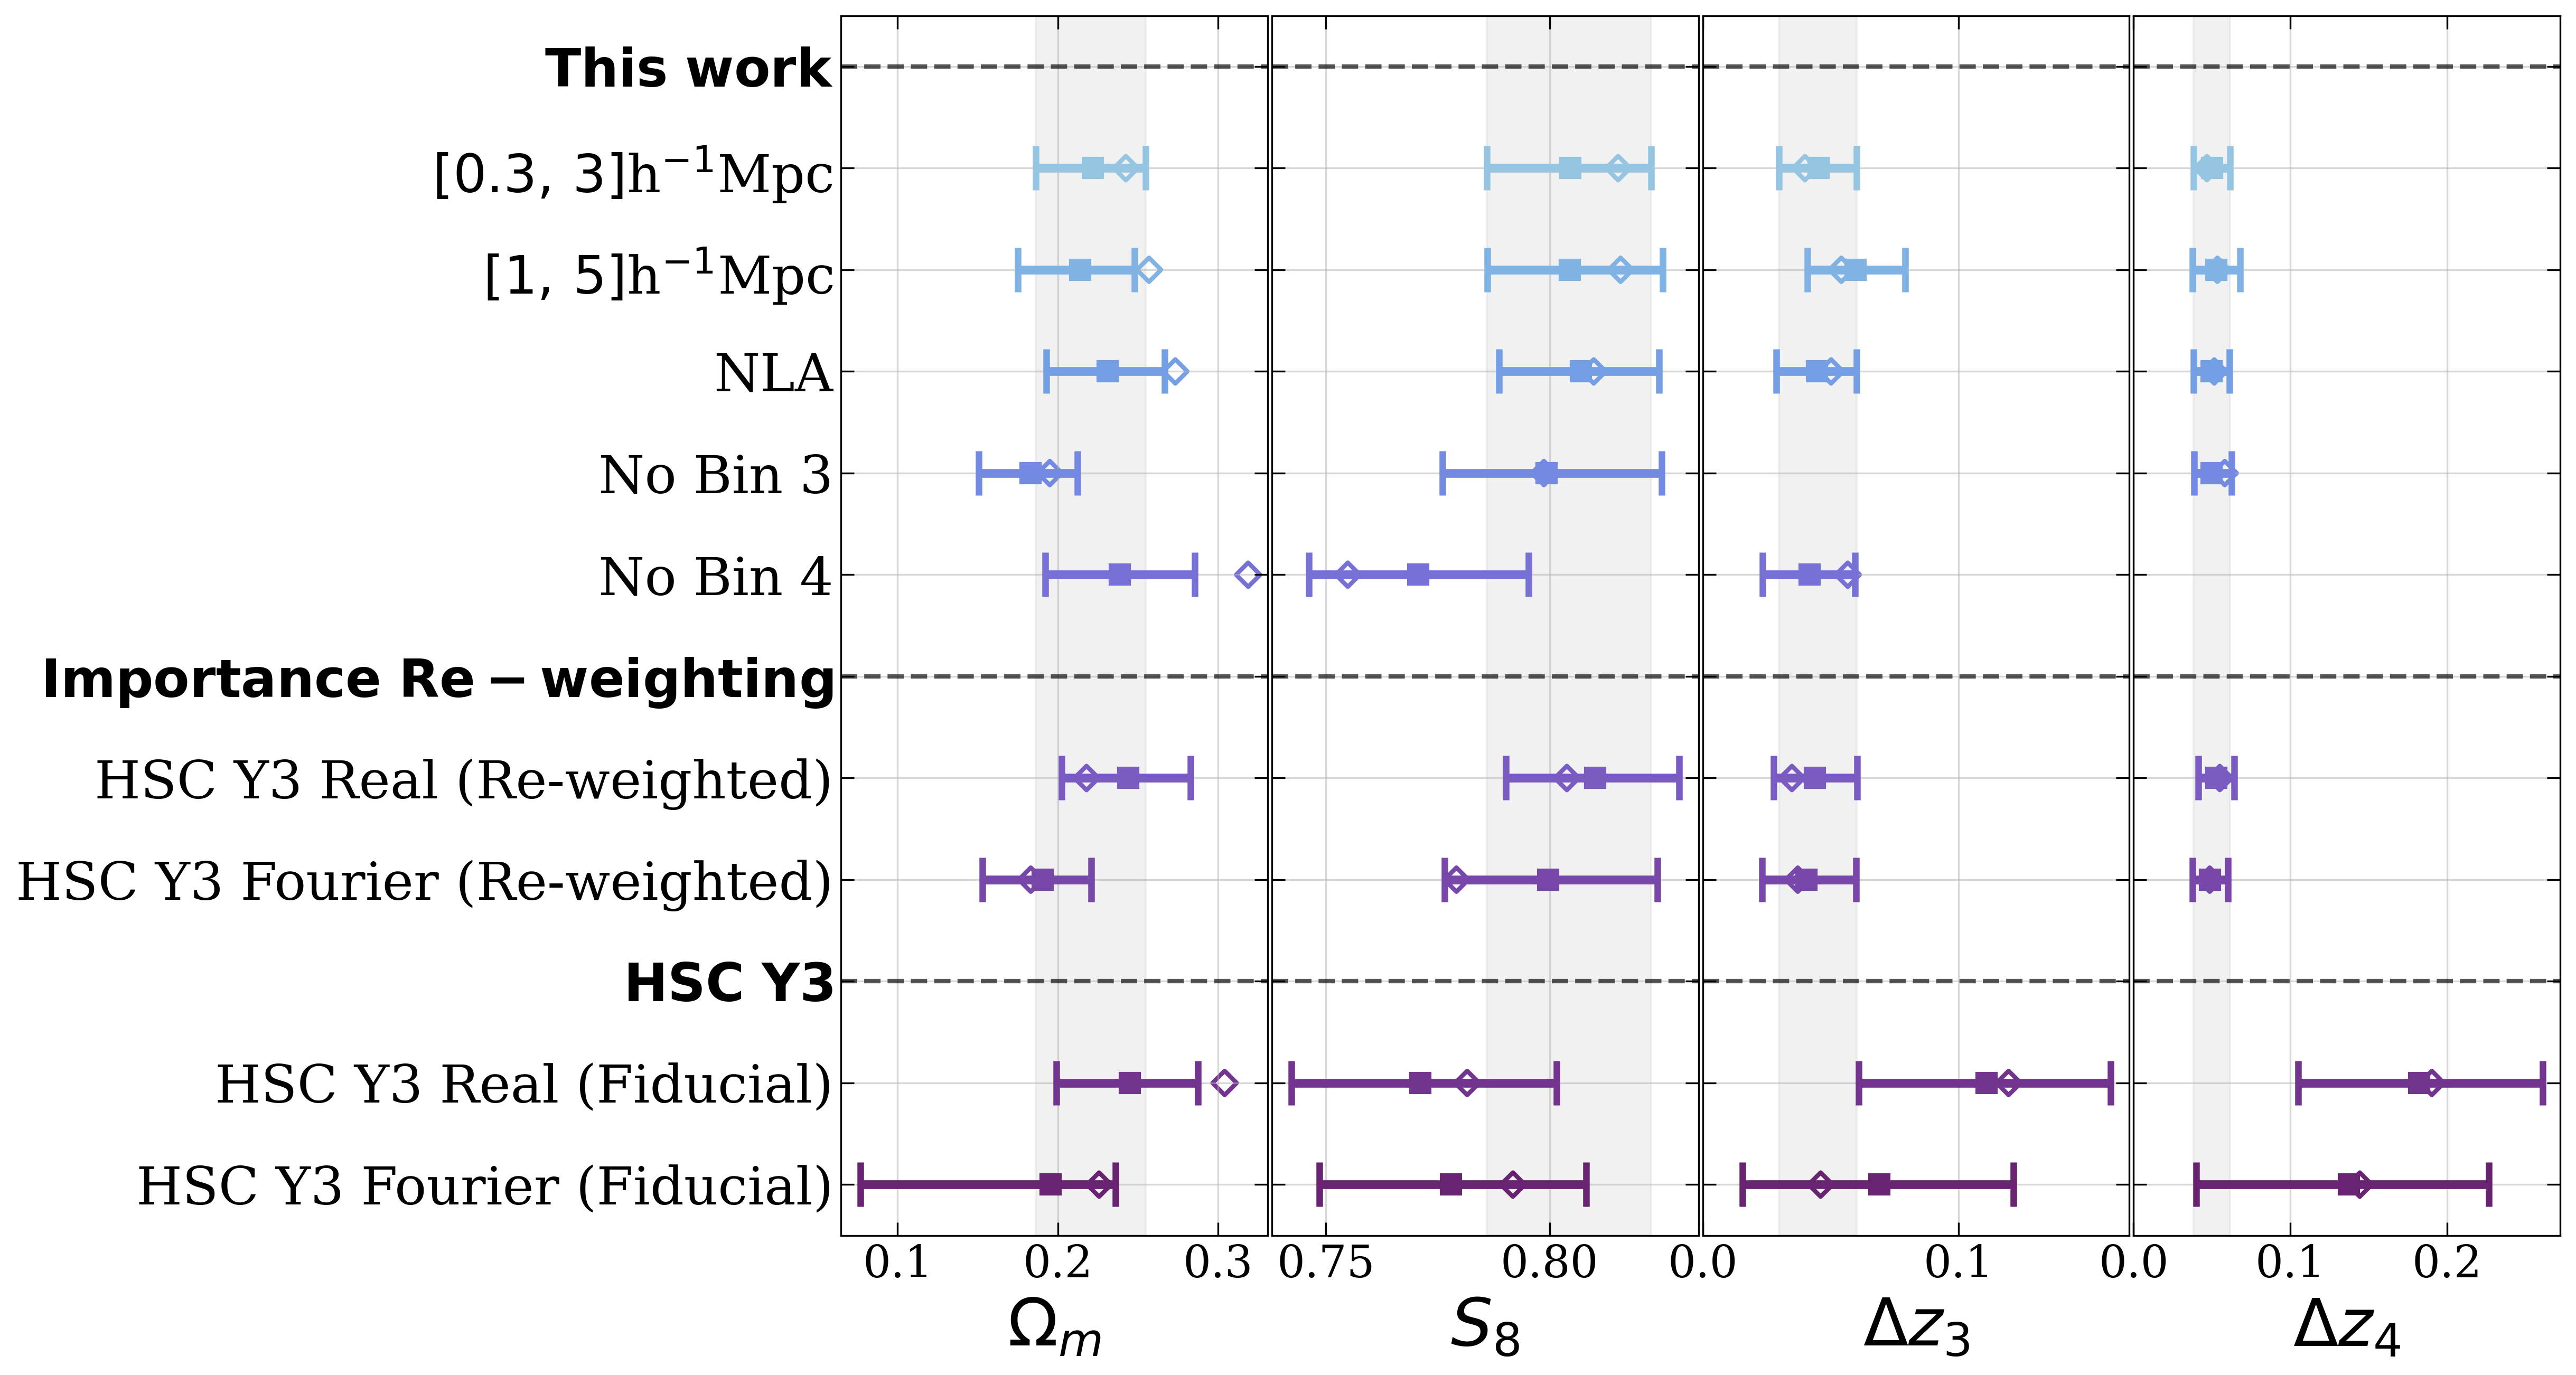

In [16]:
importlib.reload(corners)

params = [
    "cosmological_parameters--omega_m",
    "COSMOLOGICAL_PARAMETERS--S_8",
    # "COSMOLOGICAL_PARAMETERS--SIGMA_8",
    "wl_photoz_errors--bias_3",
    "wl_photoz_errors--bias_4",
]
separator_indices = [0, 5, 7]
separator_labels = [
    r"$\mathbf{This\ work}$",
    r"$\mathbf{Importance\ Re-weighting}$",
    r"$\mathbf{HSC\ Y3}$",
]
assume_symmetric_errors = True
priors = {
    "wl_photoz_errors--bias_3": (0.039, 0.020),
    "wl_photoz_errors--bias_4": (0.048, 0.012),
}

colors = cmap(np.linspace(0.2, 0.8, len(samples_list)))
n_params = len(params)
n_samples = len(samples_list)

entries = []
for i in range(n_samples):
    if i in separator_indices:
        idx = separator_indices.index(i)
        entries.append(("separator", separator_labels[idx], i))
    entries.append(("sample", chain_labels[i], i))

entries = entries[::-1]

y_positions = {entry: y for y, entry in enumerate(entries)}

ytick_labels = []
for entry_type, label, j in entries:
    ytick_labels.append(label)

yticks = np.arange(len(entries))

with pm.make_plot(
    figsize=(14, 10),
    name="tensions",
    sharey=True,
    nrows=1,
    ncols=n_params,
    show=True,
    tight_layout=False,
) as (fig, axes):

    plt.subplots_adjust(wspace=0.01)

    if n_params == 1:
        axes = [axes]

    for i, param in enumerate(params):
        ax = axes[i]

        if param not in samples_list[0].paramNames.list():
            print(f"Param {param} missing in reference, skipping")
            continue
        ref_map, ref_mode, ref_mean, ref_ci68, ref_95 = corners.analyze_param(
            ndfs[0], samples_list[0], param
        )
        ref_l68, ref_u68 = ref_ci68
        if "wl_photoz_errors" in param and not label.startswith("HSC"):
            prior_center, prior_std = priors[param]
            ref_map += prior_center
            ref_mean += prior_center
            ref_mode += prior_center
            ref_l68 += prior_center
            ref_u68 += prior_center

        ax.axvspan(ref_l68, ref_u68, color="lightgray", alpha=0.3)

        for etype, label, j in entries:
            if etype == "separator":
                y = y_positions[(etype, label, j)]
                ax.axhline(y, color="k", lw=2, ls="--", alpha=0.65)

        for etype, label, j in entries:
            if etype != "sample":
                continue

            samples = samples_list[j]
            df_post_reweight = ndfs[j]
            ew = effw[j]

            if param not in samples.paramNames.list():
                print(f"Parameter {param} not in sample {label}")
                continue

            map, mode, mean, ci68, _ = corners.analyze_param(
                df_post_reweight, samples, param
            )
            l68, u68 = ci68
            if "wl_photoz_errors" in param and not label.startswith("HSC"):
                prior_center, prior_std = priors[param]
                map += prior_center
                mean += prior_center
                mode += prior_center
                l68 += prior_center
                u68 += prior_center

            # use lower or upper error depending on the mode difference
            if assume_symmetric_errors:
                err = 0.5 * (u68 - l68)
                ref_err = 0.5 * (ref_u68 - ref_l68)
            else:
                if mode >= ref_mode:
                    err = mode - l68
                else:
                    err = u68 - mode
                # do the same for ref err
                if ref_mode >= mode:
                    ref_err = ref_mode - ref_l68
                else:
                    ref_err = ref_u68 - ref_mode

            y = y_positions[(etype, label, j)]
            color = colors[j]

            sigma = corners.compute_sigma_analytic(
                val1=mode, sig1=err, val2=ref_mode, sig2=ref_err
            )

            ax.errorbar(
                mode,
                y,
                xerr=[[mode - l68], [u68 - mode]],
                fmt="s",
                color=color,
                ecolor=color,
                elinewidth=4,
                capsize=10,
                capthick=3,
                markersize=9,
            )
            ax.scatter(
                map,
                y,
                marker="D",
                facecolors="none",
                edgecolors=color,
                linewidths=2,
                s=60,
            )

            # if (not ('$\Delta z' in params_to_labels.get(param, param)) or 'No Bin' in label) and '0.3' not in label:
            #ax.text(
            #    0.78,
            #    y + 0.3,
            #    f"{sigma:+.1f}σ",
            #    transform=ax.get_yaxis_transform(),
            #    ha="right",
            #    va="center",
            #    fontsize=18,
            #)

        if 'Delta' in params_to_labels.get(param, param):
            ax.set_xlim(0, None)
        ax.set_ylim(-0.5, len(entries) - 0.5)
        ax.grid(True, alpha=0.5, axis="x")

        if i == 0:
            ax.set_yticks(yticks)
            ax.set_yticklabels(ytick_labels, fontsize=24)
        # tick fontsize for x-axis
        ax.tick_params(axis="x", labelsize=20)

        ax.set_xlabel(params_to_labels.get(param, param), fontsize=30)

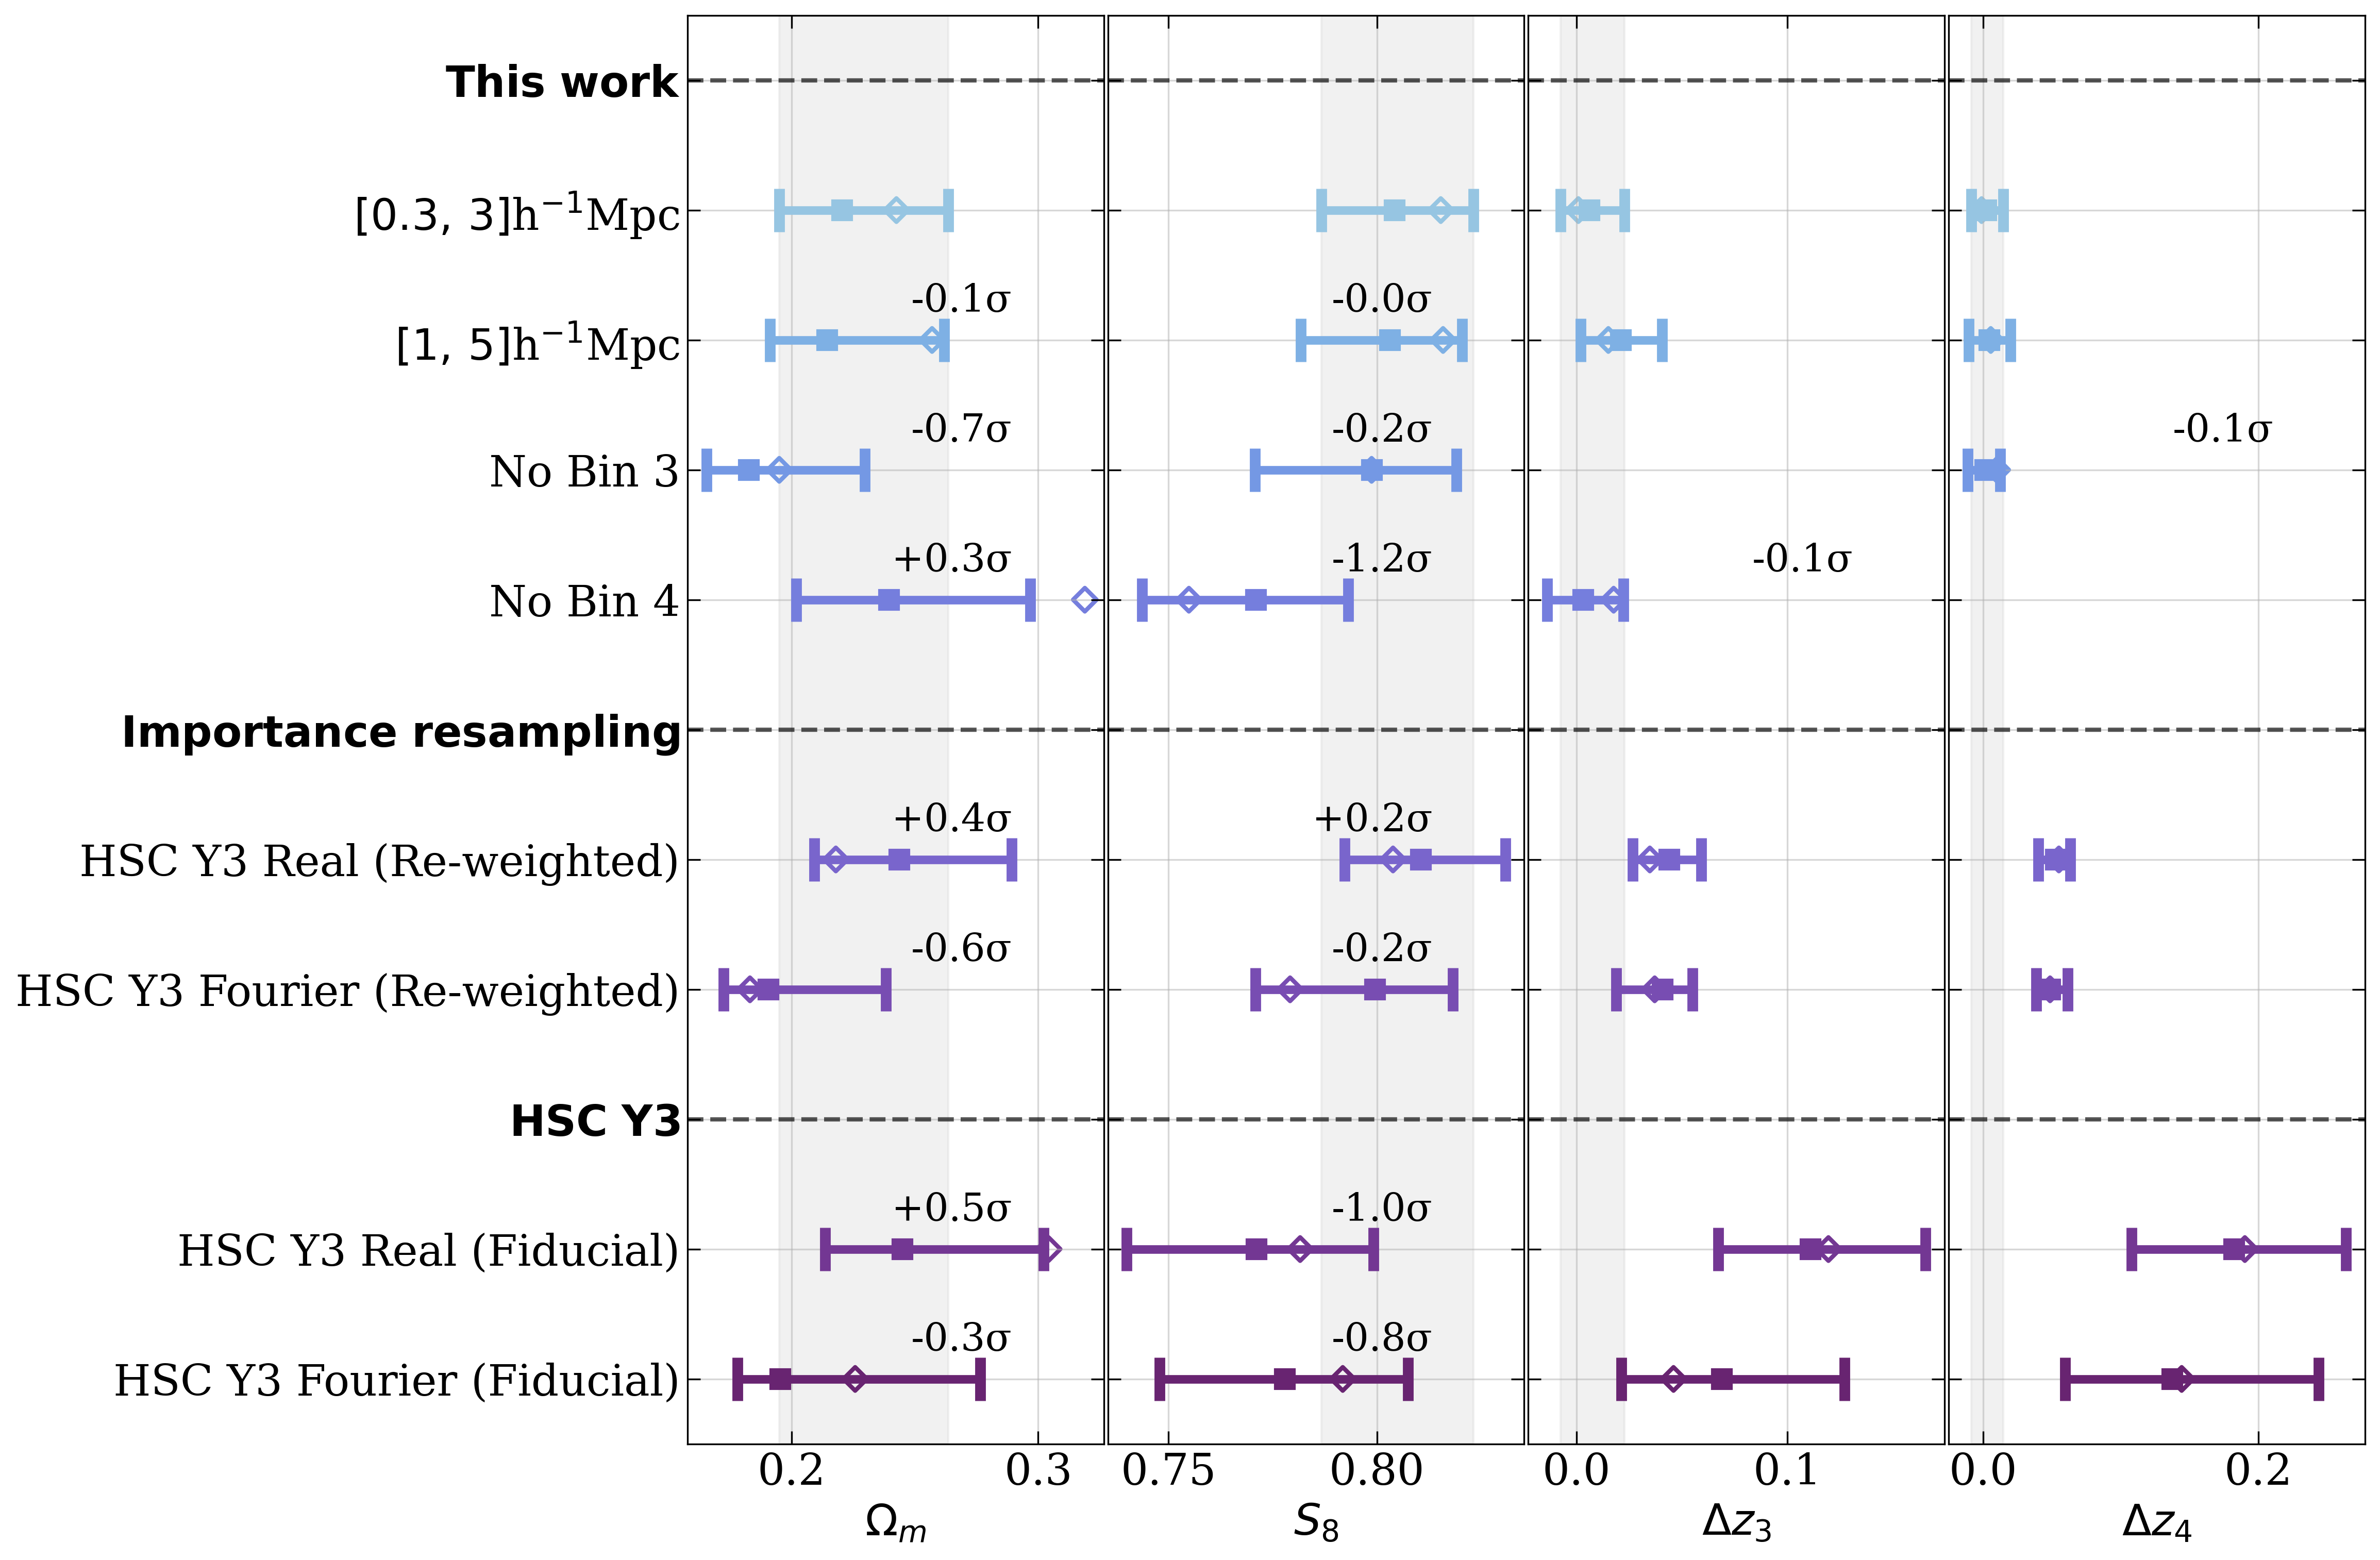

In [16]:
###### make the posterior table
## first, grab the column names as they differ ever so slightly between chains
params = [
    "cosmological_parameters--a_s",
    "cosmological_parameters--omega_m",
    "cosmological_parameters--n_s",
    "cosmological_parameters--h0",
    "cosmological_parameters--ombh2",
    "halo_model_parameters--a",
    "intrinsic_alignment_parameters--a1",
    "intrinsic_alignment_parameters--alpha1",
    "intrinsic_alignment_parameters--a2",
    "intrinsic_alignment_parameters--alpha2",
    "intrinsic_alignment_parameters--bias_ta",
    "wl_photoz_errors--bias_1",
    "wl_photoz_errors--bias_2",
    "wl_photoz_errors--bias_3",
    "wl_photoz_errors--bias_4",
    "shear_calibration_parameters--m1",
    "shear_calibration_parameters--m2",
    "shear_calibration_parameters--m3",
    "shear_calibration_parameters--m4",
    "psf_systematics_parameters--psf_cor1_z1",
    "psf_systematics_parameters--psf_cor2_z1",
    "psf_systematics_parameters--psf_cor3_z1",
    "psf_systematics_parameters--psf_cor4_z1",
    "COSMOLOGICAL_PARAMETERS--SIGMA_8",
    "COSMOLOGICAL_PARAMETERS--S_8",
]
params_hsc_real = [
    "cosmoogical_parameters--a_s",
    "cosmological_parameters--omega_m",
    "cosmological_parameters--n_s",
    "cosmological_parameters--h0",
    "cosmological_parameters--ombh2",
    "halo_model_parameters--a_bary",
    "intrinsic_alignment_parameters--a1",
    "intrinsic_alignment_parameters--alpha1",
    "intrinsic_alignment_parameters--a2",
    "intrinsic_alignment_parameters--alpha2",
    "intrinsic_alignment_parameters--bias_ta",
    "nz_sample_errors--bias_1",
    "nz_sample_errors--bias_2",
    "nz_sample_errors--bias_3",
    "nz_sample_errors--bias_4",
    "shear_calibration_parameters--m1",
    "shear_calibration_parameters--m2",
    "shear_calibration_parameters--m3",
    "shear_calibration_parameters--m4",
    "psf_systematics_parameters--psf_cor1_z1",
    "psf_systematics_parameters--psf_cor2_z1",
    "psf_systematics_parameters--psf_cor3_z1",
    "psf_systematics_parameters--psf_cor4_z1",
    "COSMOLOGICAL_PARAMETERS--SIGMA_8",
    "COSMOLOGICAL_PARAMETERS--S_8",
]
params_hsc_fourier = [
    "cosmological_parameters--a_s",
    "cosmological_parameters--omega_m",
    "cosmological_parameters--n_s",
    "cosmological_parameters--h0",
    "cosmological_parameters--ombh2",
    "halo_model_parameters--a_bary",
    "intrinsic_alignment_parameters--a1",
    "intrinsic_alignment_parameters--alpha1",
    "intrinsic_alignment_parameters--a2",
    "intrinsic_alignment_parameters--alpha2",
    "intrinsic_alignment_parameters--bias_ta",
    "wl_photoz_errors--bias_1",
    "wl_photoz_errors--bias_2",
    "wl_photoz_errors--bias_3",
    "wl_photoz_errors--bias_4",
    "shear_calibration_parameters--m1",
    "shear_calibration_parameters--m2",
    "shear_calibration_parameters--m3",
    "shear_calibration_parameters--m4",
    "psf_parameters--psf_alpha2",
    "psf_parameters--psf_beta2",
    "psf_parameters--psf_alpha4",
    "psf_parameters--psf_beta4",
    "COSMOLOGICAL_PARAMETERS--SIGMA_8",
    "COSMOLOGICAL_PARAMETERS--S_8",
]
priors = [
    r"$\mathcal{U}(0.5, 10)$",  # prior on 1e9 A_s
    r"$\mathcal{U}(0.1, 0.7)$",  # prior on Omega_m
    r"$\mathcal{U}(0.87, 1.07)$",  # prior on n_s
    r"$\mathcal{U}(0.62, 0.80)$",  # prior on h0
    r"$\mathcal{U}(0.02, 0.025)$",  # prior on ombh2
    r"$\mathcal{U}(2, 3.13)$",  # prior on A_b
    r"$\mathcal{U}(-6, 6)$",  # prior on A_1
    r"$\mathcal{U}(-6, 6)$",  # prior on eta_1
    r"$\mathcal{U}(-6, 6)$",  # prior on A_2
    r"$\mathcal{U}(-6, 6)$",  # prior on eta_2
    r"$\mathcal{U}(0, 2)$",  # prior on b_TA
    r"$\mathcal{N}(0, 0.008)$",  # prior on delta_z_1
    r"$\mathcal{N}(0, 0.009)$",  # prior on delta_z_2
    r"$\mathcal{N}(0, 0.020)$",  # prior on delta_z_3
    r"$\mathcal{N}(0, 0.012)$",  # prior on delta_z_4
    r"$\mathcal{N}(0, 0.01)$",  # prior on delta_m_1
    r"$\mathcal{N}(0, 0.01)$",  # prior on delta_m_2
    r"$\mathcal{N}(0, 0.01)$",  # prior on delta_m_3
    r"$\mathcal{N}(0, 0.01)$",  # prior on delta_m_4
    r"$\mathcal{N}(0, 1)$",  # prior on alpha_2
    r"$\mathcal{N}(0, 1)$",  # prior on beta_2
    r"$\mathcal{N}(0, 1)$",  # prior on alpha_4
    r"$\mathcal{N}(0, 1)$",  # prior on beta_4
    "--",  # sigma_8 no prior
    "--",  # S_8 no prior
]
param_labels = [
    r"$A_s\,(\times 10^9)$",
    r"$\Omega_m$",
    r"$n_s$",
    r"$h_0$",
    r"$\omega_b \equiv \Omega_b h^2$ ",
    r"$A_{\rm b}$",
    r"$A_1$",
    r"$\eta_1$",
    r"$A_2$",
    r"$\eta_2$",
    r"$b_{\rm TA}$",
    r"$\Delta z_1$",
    r"$\Delta z_1$",
    r"$\Delta z_3$",
    r"$\Delta z_4$",
    r"$\Delta m_1$",
    r"$\Delta m_2$",
    r"$\Delta m_3$",
    r"$\Delta m_4$",
    r"$\tilde{\alpha}_2$",
    r"$\tilde{\beta}_2$",
    r"$\tilde{\alpha}_4$",
    r"$\tilde{\beta}_4$",
    r"$\sigma_8$",
    r"$S_8$",
]
assert (
    len(params) == len(params_hsc_real) == len(params_hsc_fourier) == len(param_labels)
), f"{len(params)} vs {len(params_hsc_real)} vs {len(params_hsc_fourier)} vs {len(param_labels)}"
assert len(priors) == len(params), f"{len(priors)} vs {len(params)}"
rename_hsc_real = dict(zip(params_hsc_real, params))
rename_hsc_fourier = dict(zip(params_hsc_fourier, params))
param_labels_dict = dict(zip(params, param_labels))

In [32]:
### consistency checks between resampling, etc; processing data
importlib.reload(corners)
sc03_3_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-fiducial" / default_file
sc1_5_file = CHAIN_ROOT / "out-corrected-nz-real-1-5-fiducial" / default_file
nla_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-nla" / default_file
no_z3_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-no_z3" / default_file
no_z4_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-no_z4" / default_file
real_hscy3_file = CHAIN_ROOT / "ext" / "hsc_chains" / "hsc_y3_real.txt"
ps_hscy3_file = CHAIN_ROOT / "ext" / "hsc_chains" / "hsc_y3_fourier.txt"

chain_labels = [
    r"$[0.3,\,3]$" + r"h$^{-1}$Mpc",
    r"$[1,\,5]$" + r"h$^{-1}$Mpc",
    r"NLA $[0.3,\,3]$h$^{-1}$Mpc",
    "No Bin 3",
    "No Bin 4",
    "HSC Y3 Real (Re-weighted)",
    "HSC Y3 Fourier (Re-weighted)",
    "HSC Y3 Real (Fiducial)",
    "HSC Y3 Fourier (Fiducial)",
]
new_priors = {
    "wl_photoz_errors--bias_3": (0.039, 0.020),
    "wl_photoz_errors--bias_4": (0.048, 0.012),
}
params_to_labels = dict(zip(params, param_labels))

df_sc03_3, _, weights_sc03_3 = corners.load_and_process_data(sc03_3_file)
df_sc1_5, _, weights_sc1_5 = corners.load_and_process_data(sc1_5_file)
df_nla, _, weights_nla = corners.load_and_process_data(nla_file)
df_no_z3, _, weights_no_z3 = corners.load_and_process_data(
    no_z3_file, pop_params="wl_photoz_errors--bias_3"
)
df_no_z4, _, weights_no_z4 = corners.load_and_process_data(
    no_z4_file, pop_params="wl_photoz_errors--bias_4"
)
df_hscy3_real, _, weights_hscy3_real = corners.load_and_process_data(
    real_hscy3_file, rename_priors=rename_hsc_real
)
df_hscy3_fourier, _, weights_hscy3_fourier = corners.load_and_process_data(
    ps_hscy3_file, rename_priors=rename_hsc_fourier
)
df_hscy3_real_rw, _, weights_hscy3_real_rw = corners.load_and_process_data(
    real_hscy3_file, new_priors=new_priors, rename_priors=rename_hsc_real
)
df_hscy3_fourier_rw, _, weights_hscy3_fourier_rw = corners.load_and_process_data(
    ps_hscy3_file, new_priors=new_priors, rename_priors=rename_hsc_fourier
)

samples_sc03_3, ndf_sc03_3, effw_sc03_3 = corners.make_mc_sample(
    df_sc03_3,
    params,
    param_labels,
    weights_sc03_3,
    "DESI Prior (all bins)",
    burn=base_burn,
    use_log_weight=True,
)
samples_sc1_5, ndf_sc1_5, effw_sc1_5 = corners.make_mc_sample(
    df_sc1_5,
    params,
    param_labels,
    weights_sc1_5,
    "DESI Prior ([1,5])",
    burn=base_burn,
    use_log_weight=True,
)
samples_nla, ndf_nla, effw_nla = corners.make_mc_sample(
    df_nla,
    params,
    param_labels,
    weights_nla,
    r"NLA $[0.3,\,3]$h$^{-1}$Mpc",
    burn=base_burn,
    use_log_weight=True,
)
samples_no_z3, ndf_no_z3, effw_no_z3 = corners.make_mc_sample(
    df_no_z3,
    params,
    param_labels,
    weights_no_z3,
    "DESI Prior (no z3)",
    burn=base_burn,
    use_log_weight=True,
)
samples_no_z4, ndf_no_z4, effw_no_z4 = corners.make_mc_sample(
    df_no_z4,
    params,
    param_labels,
    weights_no_z4,
    "DESI Prior (no z4)",
    burn=base_burn,
    use_log_weight=True,
)
samples_hscy3_real, ndf_hscy3_real, effw_hscy3_real = corners.make_mc_sample(
    df_hscy3_real,
    params,
    param_labels,
    weights_hscy3_real,
    "HSC Y3 Real (Fiducial)",
    burn=0,
)
samples_hscy3_fourier, ndf_hscy3_fourier, effw_hscy3_fourier = corners.make_mc_sample(
    df_hscy3_fourier,
    params,
    param_labels,
    weights_hscy3_fourier,
    "HSC Y3 Fourier (Fiducial)",
    burn=0,
)
samples_hscy3_real_rw, ndf_hscy3_real_rw, effw_hscy3_real_rw = corners.make_mc_sample(
    df_hscy3_real_rw,
    params,
    param_labels,
    weights_hscy3_real_rw,
    "HSC Y3 Real (Re-weighted)",
    burn=base_burn,
)
samples_hscy3_fourier_rw, ndf_hscy3_fourier_rw, effw_hscy3_fourier_rw = (
    corners.make_mc_sample(
        df_hscy3_fourier_rw,
        params,
        param_labels,
        weights_hscy3_fourier_rw,
        "HSC Y3 Fourier (Re-weighted)",
        burn=base_burn,
    )
)

samples_list = [
    samples_sc03_3,
    samples_sc1_5,
    samples_nla,
    samples_no_z3,
    samples_no_z4,
    samples_hscy3_real_rw,
    samples_hscy3_fourier_rw,
    samples_hscy3_real,
    samples_hscy3_fourier,
]
ndfs = [
    ndf_sc03_3,
    ndf_sc1_5,
    ndf_nla,
    ndf_no_z3,
    ndf_no_z4,
    ndf_hscy3_real_rw,
    ndf_hscy3_fourier_rw,
    ndf_hscy3_real,
    ndf_hscy3_fourier,
]
effw = [
    effw_sc03_3,
    effw_sc1_5,
    effw_nla,
    effw_no_z3,
    effw_no_z4,
    effw_hscy3_real_rw,
    effw_hscy3_fourier_rw,
    effw_hscy3_real,
    effw_hscy3_fourier,
]
mask_in_table = [True, True, True, True, True, True, True, True, True]

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [33]:
## format a latex table into a txt file
out_table = Path("summaries/posterior_table.txt")
out_table.parent.mkdir(exist_ok=True)

with open(out_table, "w") as f:
    header = "Parameter & Prior "
    for label in chain_labels:
        if not mask_in_table[chain_labels.index(label)]:
            continue
        header += f"& {label} "
    header += "\\\\ \n"
    f.write(header)
    f.write("\\hline\n")

    n_params = len(params)
    n_samples = len(samples_list)

    for i in range(n_params):
        param = params[i]
        print(f"Processing param {param}...")
        row = f"{param_labels_dict.get(param, param)} & {priors[i]} "
        for j in range(n_samples):
            if not mask_in_table[j]:
                continue
            samples = samples_list[j]
            df_post_reweight = ndfs[j]
            if param not in samples.paramNames.list():
                row += "& -- "
                continue
            map, mode, mean, ci68, ci95 = corners.analyze_param(
                df_post_reweight, samples, param
            )
            l68, u68 = ci68

            if "cosmological_parameters--a_s" in param:
                map *= 1e9
                mode *= 1e9
                mean *= 1e9
                l68 *= 1e9
                u68 *= 1e9

            row += f"& ${mode:.3f}_{{-{mode - l68:.3f}}}^{{+{u68 - mode:.3f}}} ({{{map:.3f}}})$ "
        row += "\\\\ \n"
        f.write(row)

Processing param cosmological_parameters--omega_m...


KeyError: 0